# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [2]:
%matplotlib inline

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Set figures save path

In [4]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures

In [6]:
save_prefix = r"../results/behavior/"
if SAVE_FIGS:
    import pathlib
    try:
        pathlib.Path(save_prefix).mkdir(exist_ok=True)
    except:
        print("Failed to create save dir...")

# Common function for mice and human data

In [7]:
COLOR_ACCURACY = "#6e286a"
COLOR_MAX_OUTCOME = "#1ba08e"
COLOR_MICE = "#eb8b2d"

In [8]:
import numpy as np
from typing import Literal

def plotSTVsTime(df, *, dv_col, st_col, is_many_subjects, ax, ls, c="k",
                 use_mean_or_median : Literal["mean", "median"]="mean",
                 center=False):
    assert use_mean_or_median in ["mean", "median"]
    x = []
    y = []
    y_sem = []
    label = st_col
    for dv in ["Hard", "Med", "Easy"]:
        dv_df = df[df[dv_col] == dv]
        if is_many_subjects:
            col = dv_df.groupby("Name")[st_col].mean()
            label = f"{label}\n({dv} n={len(col)} subjects)"
        else:
            col = dv_df[st_col]
        if use_mean_or_median == "mean":
            y.append(col.mean())
            y_sem.append(col.sem())
        else:
            y.append(col.median())
            y_sem.append(0)
        x.append(dv)
    if center:
        y = np.array(y)
        y -= y.mean()
    ax.errorbar(x, y, yerr=y_sem, ls=ls, label=label, c=c)


In [9]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignQuantiles(df):
    df = df.copy()
    # Some files are saved twice due to cloud sync issues
    uniq_cols = ["Name", "Date", "SessionNum", "TrialNumber", "TrialStartSysTime"]

    len_before = len(df)
    df = df[~df[uniq_cols].duplicated(keep="first")]
    assert len(df) == len_before, "Some rows are duplicated"
    null_time = df.calcStimulusTime.isnull()
    df_null_time = df[null_time]
    print(f"Num null stimulus time: {len(df_null_time)}/{len(df)}")
    df = df[~null_time]
    df = splitStimulusTimeByQuantile(df)
    df = pd.concat([q_df for q_idx, q_df in df] + [df_null_time])
    return df

# Load data

## Mice data

In [10]:
_FP = "../data/behavior/df_behavior.pkl"
df_mice = pd.read_pickle(_FP)
# Exclude first 30 trials of each session, optogenetics trials, trials where mice
# stayed more than 5 sec in the center port, i.e. stimulus is no loger presented,
# and exclude early-withdrawal trials, i.e. mice stayed for less than 0.3s
df_mice = df_mice[df_mice["valid"]]

In [11]:
df_chrono = pd.read_pickle(r"../data/behavior/df_chrono.pkl")

In [12]:
lc_hf_combined_df = pd.read_pickle(r"../data/behavior/lc_hf_combined_df.pkl")

## Humans data

In [13]:
df_users = pd.read_pickle(r"../data/behavior/df_human_subjects.pkl")

In [14]:
humans_max_outcome_df = df_users[df_users.session_type == "Competition"]
humans_accuracy_df = df_users[df_users.session_type == "ReactionTime"]

# Plot Stimulus-Time Distribution

## Fig. 1d

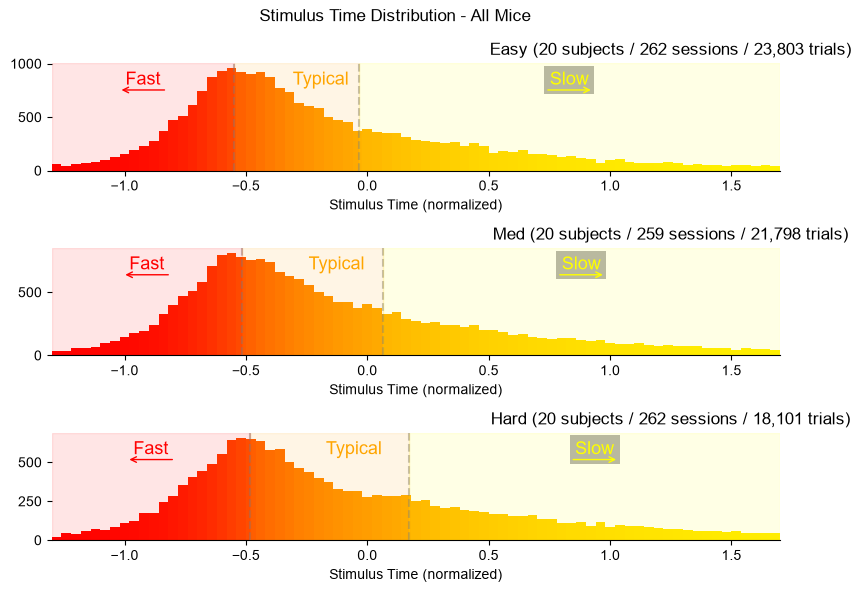

In [15]:
from .figcode.stbydifficulty import stDistOnly

stDistOnly(df_mice, plot_single_subjects=False,
           save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Ext Fig. 2d

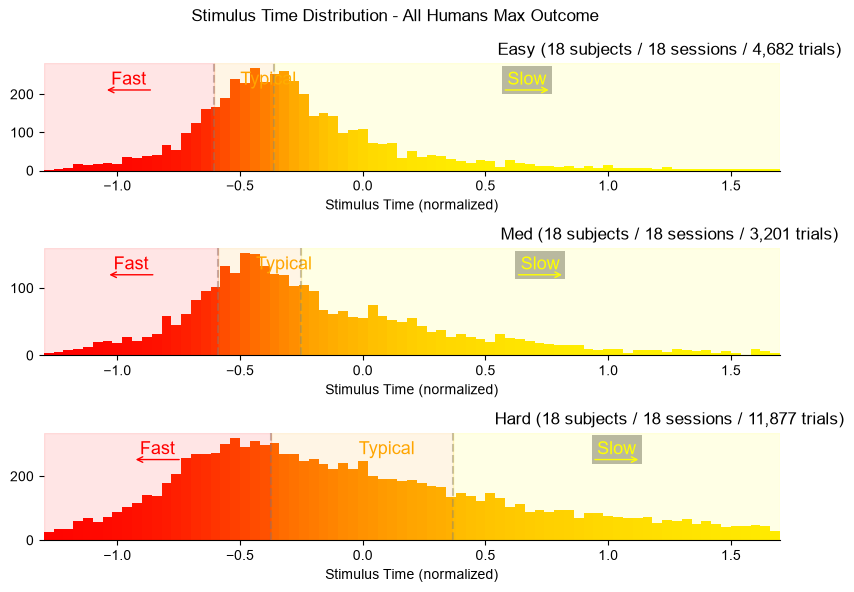

In [16]:
stDistOnly(humans_max_outcome_df, plot_single_subjects=False,
           descrp="Humans Max Outcome",
           save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Ext Fig. 2g

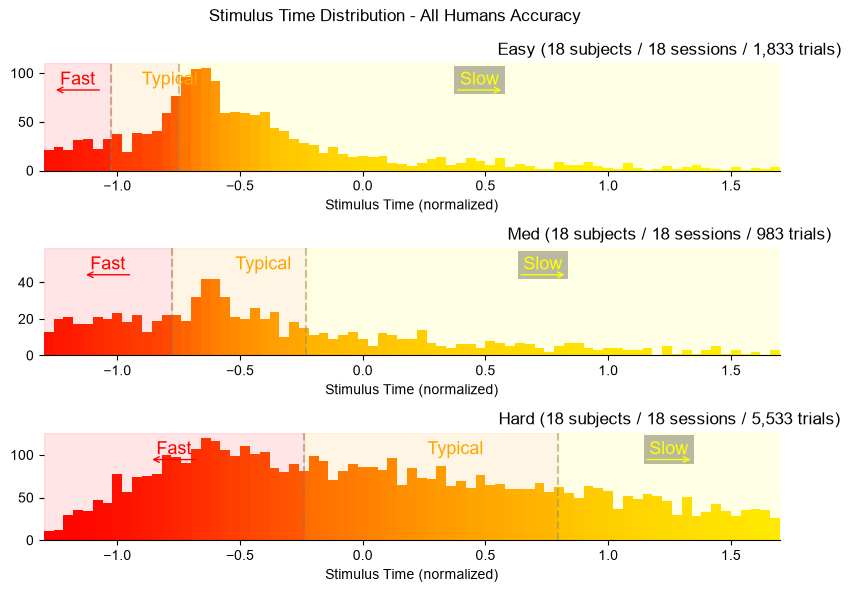

In [17]:
stDistOnly(humans_accuracy_df, plot_single_subjects=False,
           descrp="Humans Accuracy",
           save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Ext Fig. 2j

GP4-85


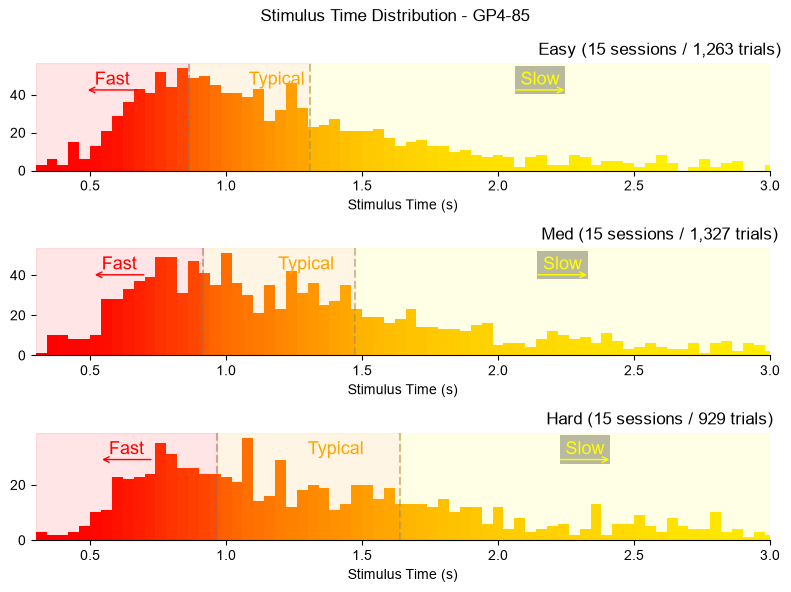

In [18]:
from .figcode.stbydifficulty import stDistOnly

stDistOnly(df_mice[df_mice.Name == "GP4-85"],
           plot_single_subjects=True, plot_combined_subjects=False,
           save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Per subject plots

In [19]:
stDistOnly(df_mice, plot_single_subjects=True, plot_combined_subjects=False,
           save_prefix=save_prefix, save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY)

Avgat1


Avgat2


Avgat3


BVGAT1


GP4-24


...

vgat-95


vgat-96


vgat2.5


vgatchr2-sk


widefield_1


# Plot Fast/Slow Reaction-Time vs Difficulty

biggest_rng: 0.4


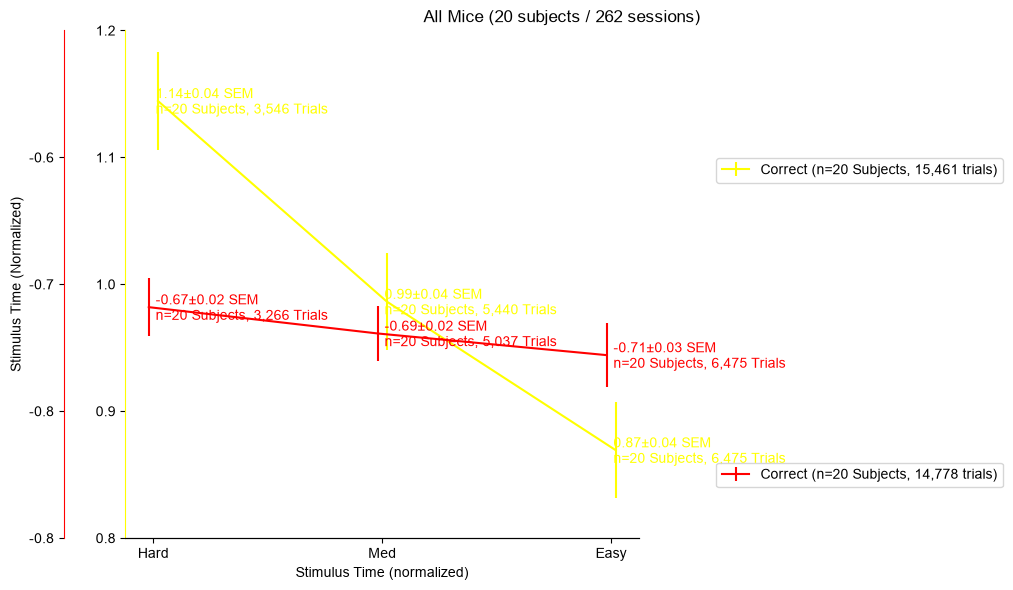

In [20]:
from .figcode.stbydifficulty import stVsDiffOnly

stVsDiffOnly(df_mice,#.groupby("Name").filter(lambda subj_Df: len(subj_Df) > 2_500),
             plot_single_subjects=False,
             y_fast_min=-.85, y_slow_min=0.8,
             save_prefix=save_prefix, save_figs=SAVE_FIGS)

In [21]:
from .figcode.stbydifficulty import stVsDiffOnly
pathlib.Path(f"{save_prefix}/humans_st/").mkdir(exist_ok=True)

## Fig. 1g-right

biggest_rng: 2.0


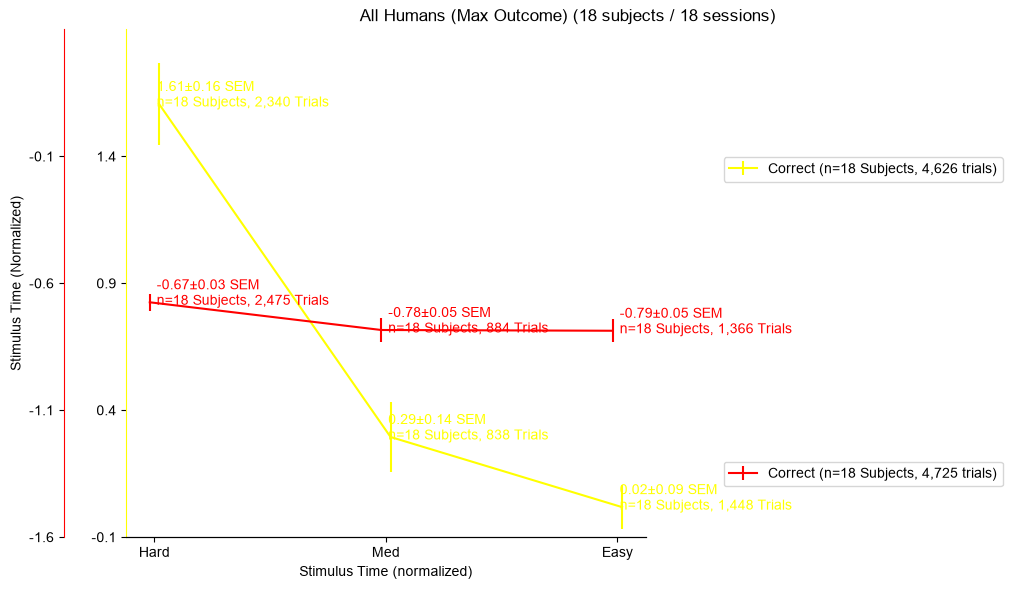

In [22]:
stVsDiffOnly(humans_max_outcome_df, plot_single_subjects=False,
             save_prefix=f"{save_prefix}/humans_st/max_outcome",
             y_fast_min=-1.6, y_slow_min=-.1,
             all_dscrp="All Humans (Max Outcome)",
             save_figs=SAVE_FIGS)

## Ext Fig. 2a

biggest_rng: 2.4


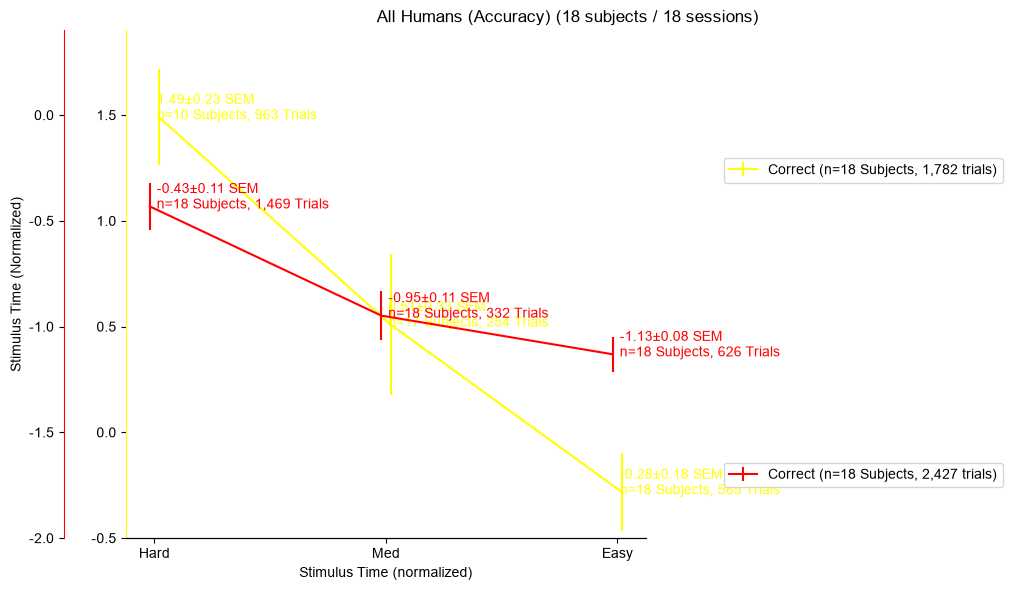

In [23]:
stVsDiffOnly(humans_accuracy_df, plot_single_subjects=False,
             save_prefix=f"{save_prefix}/humans_st/accuracy",
             y_fast_min=-2, y_slow_min=-.5,
             all_dscrp="All Humans (Accuracy)",
             save_figs=SAVE_FIGS)

# More Human data

## Plot user data

Accuracy Competition - Num of subjects: 18 - Num of trials: 8,349
Maximizing Correct-Outcome Competition - Num of subjects: 18 - Num of trials: 19,760
Mice - Num of subjects: 20 - Num of trials: 63,668
Accuracy Competition
 (n=18 Subjects,
8,349 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.9382149080703005), pvalue=np.float64(0.27003940538413373))
Maximizing Correct-Outcome Competition
 (n=18 Subjects,
19,760 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.8916684068980795), pvalue=np.float64(0.041223203628948414))
Mice
 (n=20 Subjects,
63,668 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.9483543032504155), pvalue=np.float64(0.34279928146352845))
Data is not normal
kruskal statistics: 41.454051796157046 p_val: 9.962469990460734e-10
post_hoc_str: Dunn's test with holm correction


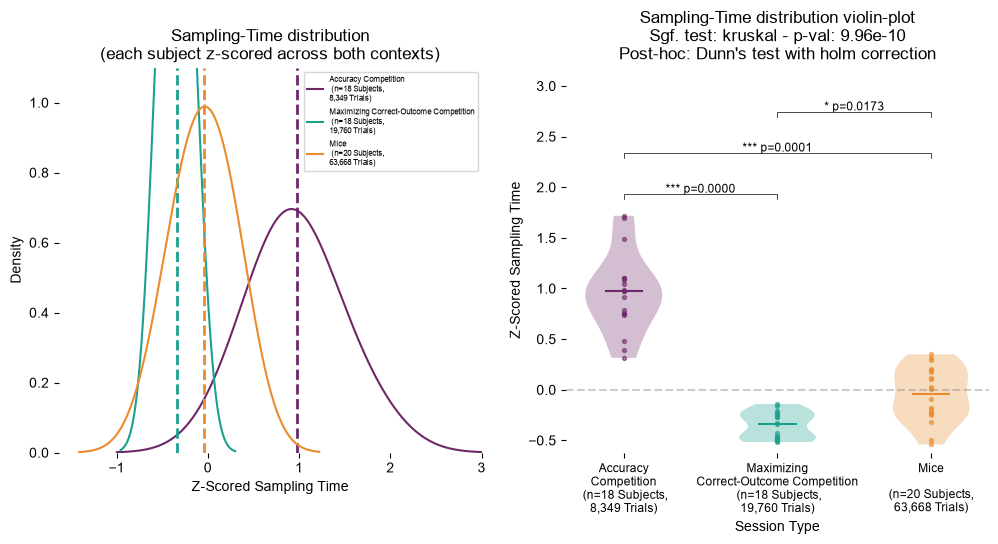

In [24]:
from .behavior.stdistribution import plotSTDistribution

# Each subject is z-scored once across BOTH contexts and only then split, so
# the between-context difference survives. Mice have a single context, where
# that rule is degenerate, so they are pooled across animals instead (see the
# module docstring).
S2B_COLORS = {"Accuracy Competition": COLOR_ACCURACY,
              "Maximizing Correct-Outcome Competition": COLOR_MAX_OUTCOME,
              "Mice": COLOR_MICE}
S2B_SESSIONS = [("Accuracy Competition", "ReactionTime"),
                ("Maximizing Correct-Outcome Competition", "Competition")]

s2b_stats = plotSTDistribution(df_users, df_mice, colors=S2B_COLORS,
                               session_types=S2B_SESSIONS,
                               save_prefix=save_prefix,
                               save_figs=SAVE_FIGS)

### Per-subject z-scored sampling time & subject-sigma dispersion

Accuracy Competition - Num of subjects: 18 - Num of trials: 8,349
Maximizing Correct-Outcome Competition - Num of subjects: 18 - Num of trials: 19,760
Mice - Num of subjects: 20 - Num of trials: 63,668


Accuracy Competition
 (n=18 Subjects,
8,349 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.9320571149339217), pvalue=np.float64(0.2110287131158733))
Maximizing Correct-Outcome Competition
 (n=18 Subjects,
19,760 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.8967060881209084), pvalue=np.float64(0.050362257256327835))
Mice
 (n=20 Subjects,
63,668 Trials) - Normality test: ShapiroResult(statistic=np.float64(0.9506987768638283), pvalue=np.float64(0.37782150080871035))
Data is normal
f_oneway statistics: 30.184269972937596 p_val: 1.775243280702624e-09
post_hoc_str: Tukey's HSD test


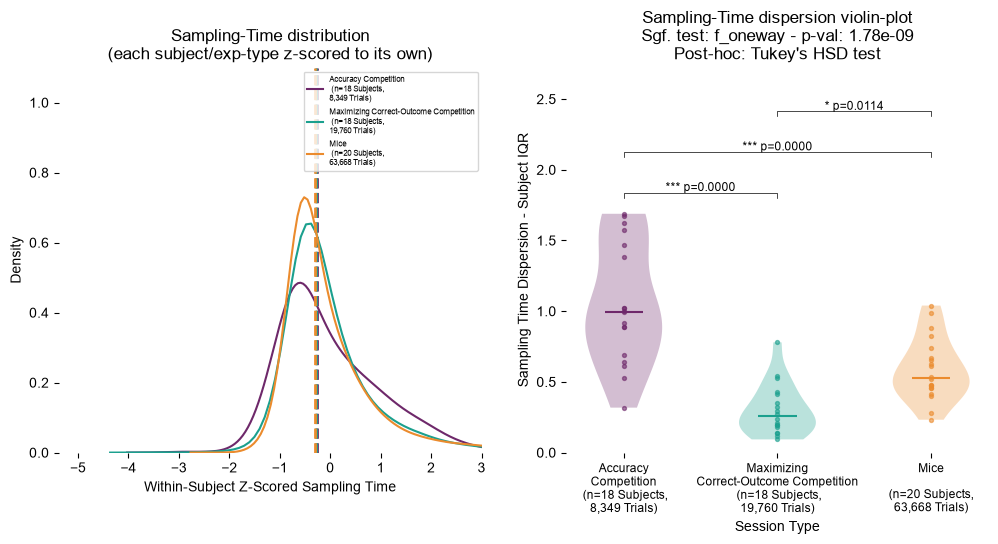

In [25]:
from .behavior.stdispersion import plotSTDispersion

# Same figure as above but: (1) each human subject x experiment-type is
# z-scored to its own trials (instead of the subject's session types being
# pooled), (2) each mouse is z-scored to its own trials (instead of pooling
# across animals), and (3) the right panel shows the dispersion of the raw
# (seconds) sampling time -- sigma or IQR, see DISPERSION_MEASURE below -- one
# point per subject x experiment-type. The z-scored dispersion is 1.0 for every
# subject by construction, hence the raw column there; likewise every subject's
# z-scored mean is 0, so the left panel shows the trial-level z-scores rather
# than subject means.
SESSION_TYPES = [("Accuracy Competition", "ReactionTime"),
                 ("Maximizing Correct-Outcome Competition", "Competition")]
GROUP_COLORS = {"Accuracy Competition": COLOR_ACCURACY,
                "Maximizing Correct-Outcome Competition": COLOR_MAX_OUTCOME,
                "Mice": COLOR_MICE}

# "std" -> subject sigma, "iqr" -> subject inter-quartile range (robust to the
# long right tail). Each measure saves under its own file name.
DISPERSION_MEASURE = "iqr"

_ = plotSTDispersion(df_users, animals_df=df_mice, colors=GROUP_COLORS,
                     session_types=SESSION_TYPES,
                     measure=DISPERSION_MEASURE,
                     save_fp=save_prefix, save_figs=SAVE_FIGS)

## Humans fast/slow mean performance

## Ext. Fig. 2l

Humans Accuracy: n=18, p=0.1653, Holm p=0.1653
Humans Max Outcome: n=18, p=0.0029, Holm p=0.0058
Mice: n=20, p=0.0001, Holm p=0.0004


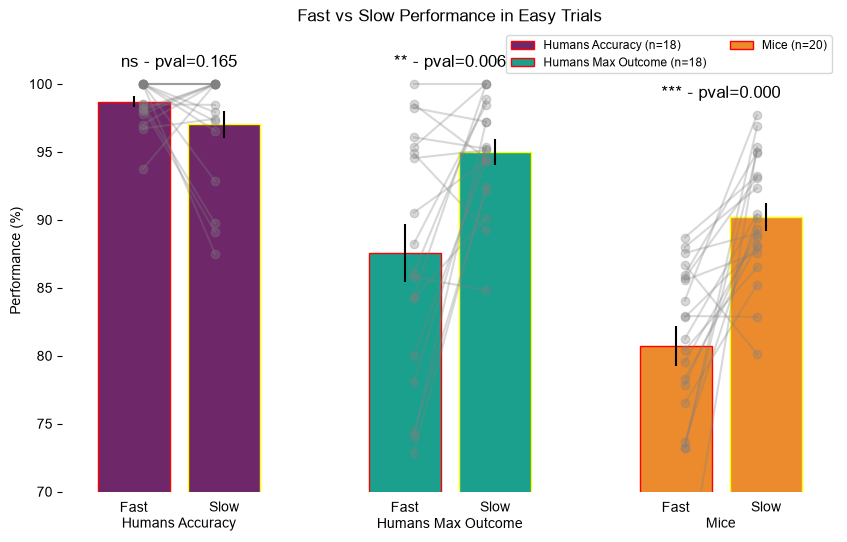

In [26]:
from .behavior.fastslowperf import collectAllGroups, plotFastSlowAccuracy

# Easy trials only, so a fast/slow accuracy gap cannot be blamed on the
# stimulus. Paired within subject, Holm-corrected across the three contexts.
s2m_results = collectAllGroups(humans_accuracy_df, humans_max_outcome_df,
                               df_mice)
for _r in s2m_results:
    print(f"{_r.label}: n={_r.n_subjects}, p={_r.pvalue:.4f}, "
          f"Holm p={_r.pvalue_corrected:.4f}")
_ = plotFastSlowAccuracy(s2m_results, save_prefix=save_prefix,
                         save_figs=SAVE_FIGS)

# Psychometric (overall) - Humans & Mice

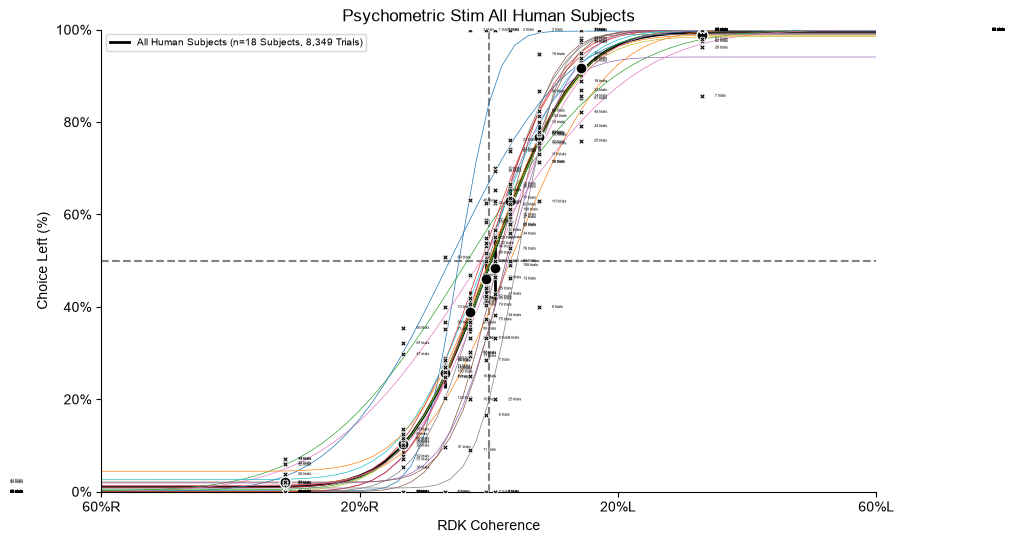

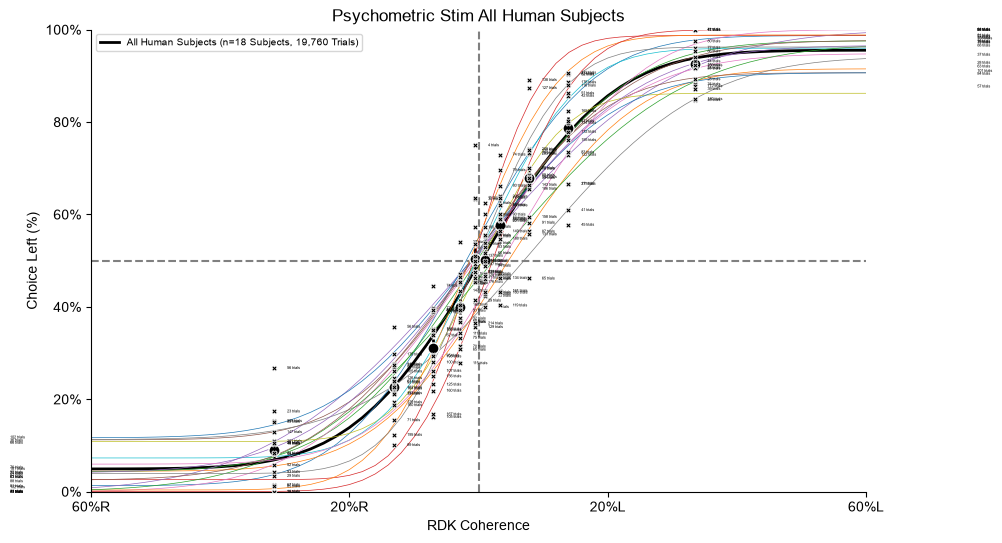

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychometric.py:451: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stim_ratio_sem.append(stats.sem(perf_col))


Mean: 33.714285714285715 - SEM: nan - len(perf_col): 1


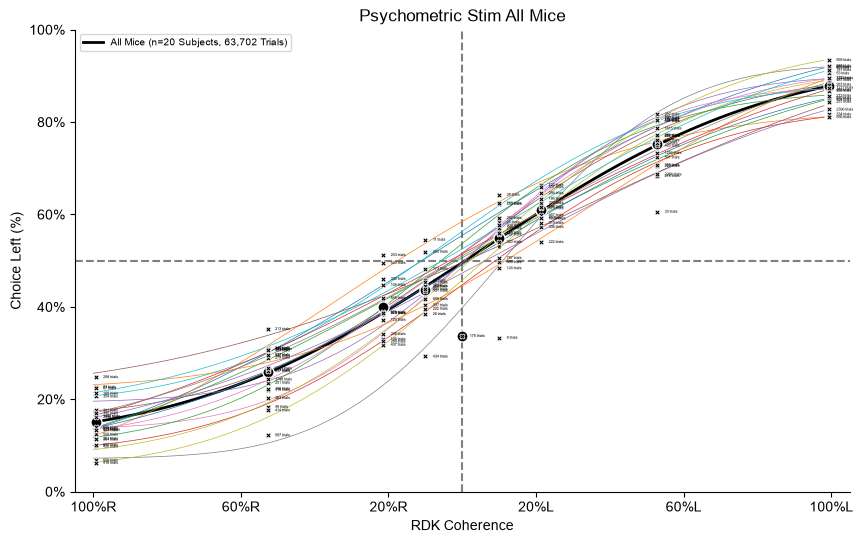

In [27]:
from .figcode.psychometric import loopPsych

def localSPsych(humans_accuracy_df, humans_max_outcome_df, df_animals, save_fp="", save_figs=SAVE_FIGS,):
    for sess_type, cur_df, is_human in [("Accuracy Competition", humans_accuracy_df, True),
                                        ("Maximizing Correct-Outcome Competition", humans_max_outcome_df, True),
                                        ("Mice", df_animals, False),
                                    ]:
        loopPsych(cur_df, title=sess_type, is_human_subject=is_human,
                  combine_sides=False, save_fp=f"{save_fp}/psych/",
                  plot_single_subjects=False,
                  save_figs=save_figs)


localSPsych(humans_accuracy_df, humans_max_outcome_df, df_animals=df_mice,
            save_fp=save_prefix, save_figs=SAVE_FIGS)

# RT vs Difficulty (overall) - Humans & Mice

In [28]:
from .figcode.stbydifficulty import loopstVsDiffOnly


## Ext. Fig 2e

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly
GP4-85


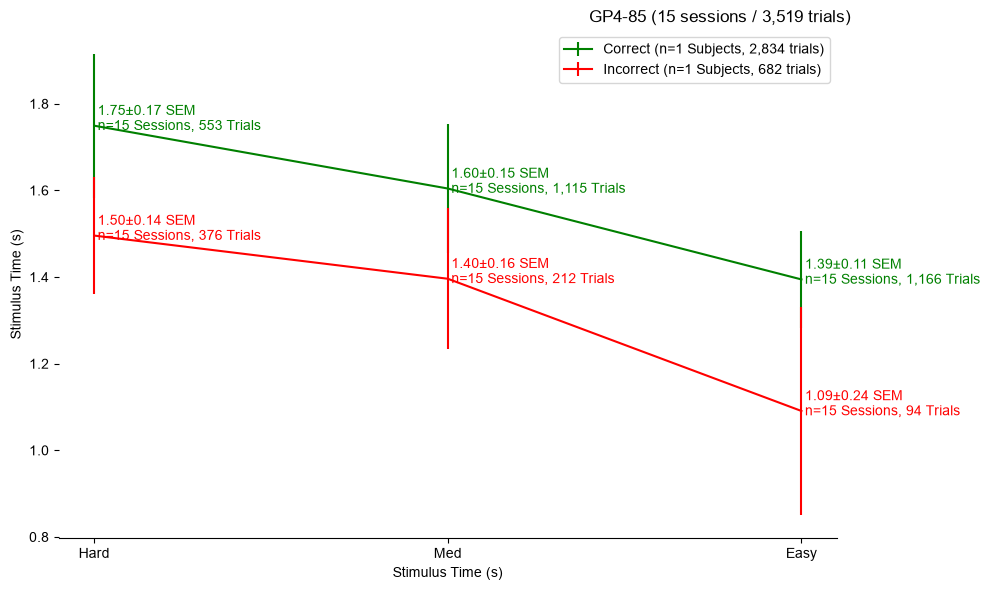

In [29]:
loopstVsDiffOnly(df_mice[df_mice.Name == "GP4-85"],
                 title="Mice",
                 plot_combined_subjects=False,
                 plot_single_subjects=True,
                 save_prefix=f"{save_prefix}/",  save_figs=SAVE_FIGS)

## Ext. Fig 2h

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly


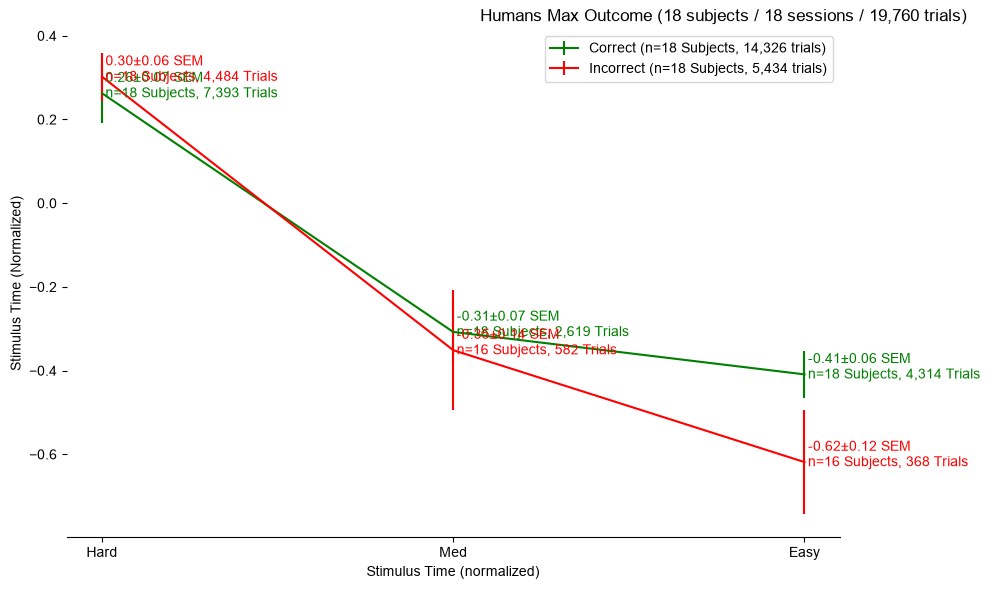

In [30]:

loopstVsDiffOnly(humans_max_outcome_df, title="Humans Max Outcome", plot_single_subjects=False,
                 save_prefix=f"{save_prefix}/",  save_figs=SAVE_FIGS)

## Ext. Fig 2k

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly


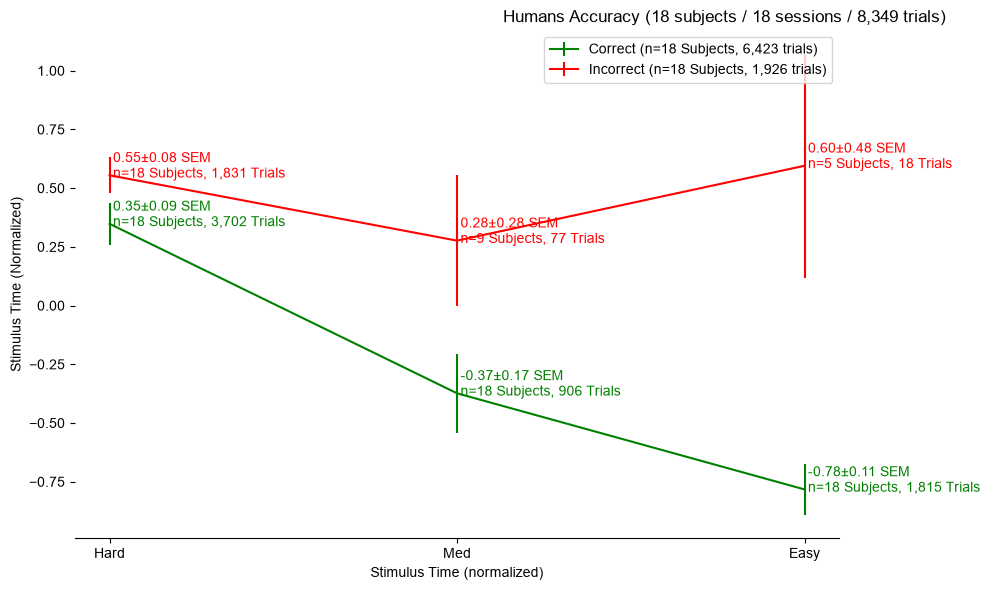

In [31]:
from .figcode.stbydifficulty import loopstVsDiffOnly

loopstVsDiffOnly(humans_accuracy_df, title="Humans Accuracy", plot_single_subjects=False,
                 save_prefix=f"{save_prefix}/",  save_figs=SAVE_FIGS)

## Per subject figures

In [32]:
loopstVsDiffOnly(df_mice,
                 title="Mice",
                 plot_combined_subjects=False,
                 plot_single_subjects=True,
                 save_prefix=f"{save_prefix}/",  save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY)

TODO: Rename this function and the function below to: fastSlowStVsDIffOnly
Avgat1


Avgat2


Avgat3


BVGAT1


GP4-24


...

vgat-95


vgat-96


vgat2.5


vgatchr2-sk


widefield_1


# Priors effect on current trial stimulus time

# Reaction-Time Heatmap

## Ext. Fig 2e-right, f

df.min(): -0.14006728627566162


	Prev. Not-Rewarded, Cur. Hard, Prev.Easy	Prev. Not-Rewarded, Cur. Hard, Prev.Hard	Prev. Not-Rewarded, Cur. Easy, Prev.Easy	Prev. Not-Rewarded, Cur. Easy, Prev.Hard	Prev. Rewarded, Cur. Hard, Prev.Easy	Prev. Rewarded, Cur. Hard, Prev.Hard	Prev. Rewarded, Cur. Easy, Prev.Easy	Prev. Rewarded, Cur. Easy, Prev.Hard	
Prev. Not-Rewarded, Cur. Hard, Prev.Easy	1.00000	0.24316	0.20548	0.10948	0.00860	0.05175	0.00000	0.00000	
Prev. Not-Rewarded, Cur. Hard, Prev.Hard	0.24316	1.00000	0.01497	0.00565	0.00015	0.00186	0.00000	0.00000	
Prev. Not-Rewarded, Cur. Easy, Prev.Easy	0.20548	0.01497	1.00000	0.73805	0.17331	0.49707	0.00080	0.00005	
Prev. Not-Rewarded, Cur. Easy, Prev.Hard	0.10948	0.00565	0.73805	1.00000	0.30433	0.73034	0.00255	0.00022	
Prev. Rewarded, Cur. Hard, Prev.Easy	0.00860	0.00015	0.17331	0.30433	1.00000	0.49491	0.04664	0.00754	
Prev. Rewarded, Cur. Hard, Prev.Hard	0.05175	0.00186	0.49707	0.73034	0.49491	1.00000	0.00754	0.00079	
Prev. Rewarded, Cur. Easy, Prev.Easy	0.00000	0.00000	0.000

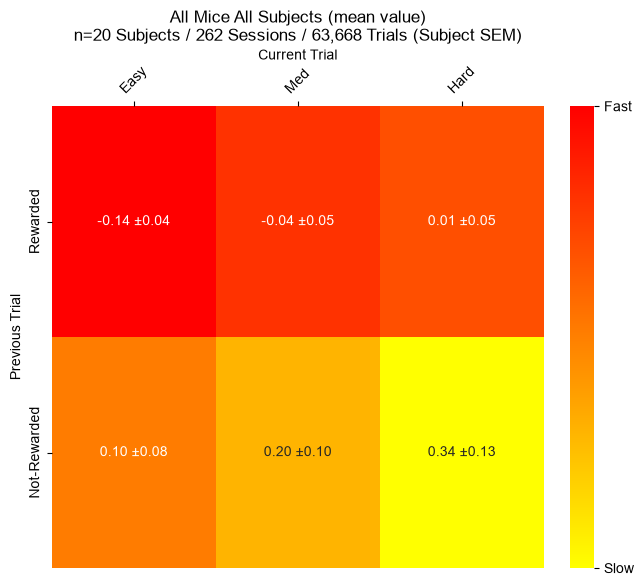

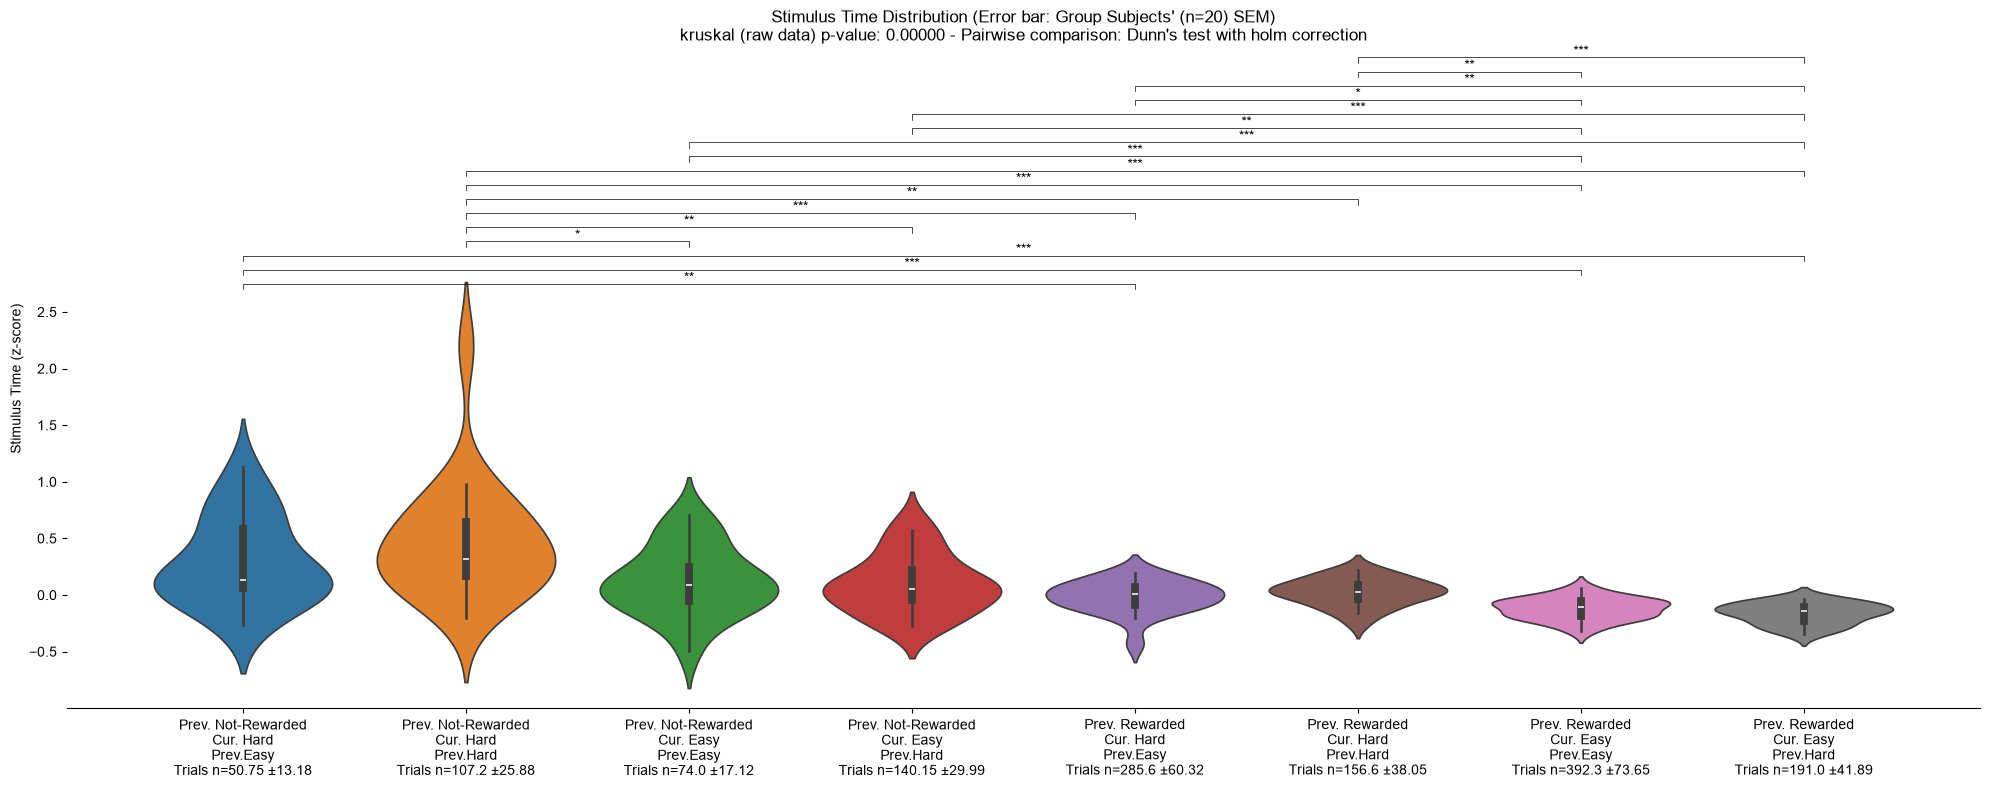

In [33]:
from .figcode.stheatmap import stHeatmap

stHeatmap(df_mice.copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=SAVE_FIGS)

## Fig 2e left

vgat2.5
df.min(): 0.9217221995926681


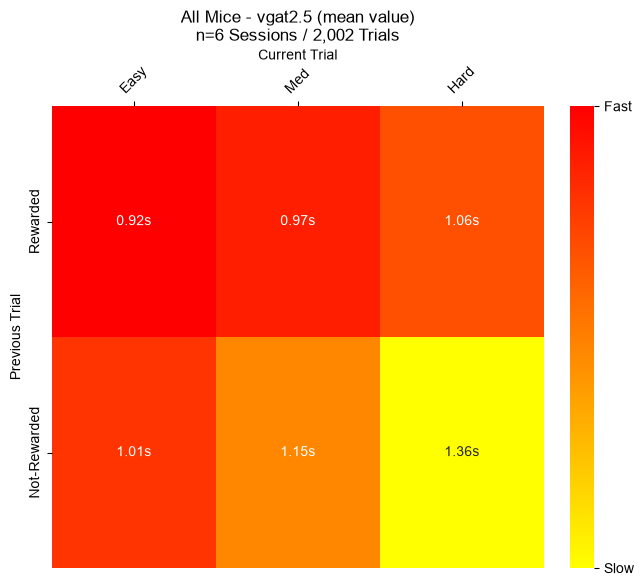

In [34]:
stHeatmap(df_mice[df_mice.Name == "vgat2.5"].copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=True,
          plot_combined_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=SAVE_FIGS)

## Per subject plots

In [35]:
stHeatmap(df_mice.copy(), dscrp="All Mice",
          mean_or_median="mean",
          plot_single_subjects=True,
          plot_combined_subjects=False,
          save_prefix=f"{save_prefix}/rt_prev_cur/",
          save_fig=SAVE_FIGS and not PAPER_FIGURES_ONLY)

Avgat1
df.min(): 0.7182625906735751


Avgat2
df.min(): 0.849068154158215


Avgat3
df.min(): 0.7487653259361996


BVGAT1
df.min(): 1.0618671641791044


GP4-24
df.min(): 0.9389766666666667


...

vgat-96
df.min(): 0.9495280429594272


vgat2.5
df.min(): 0.9217221995926681


vgatchr2-sk
df.min(): 0.9412552575107297


widefield_1


df.min(): 0.8729522388059702


# Prev. Trial Effect on Current Trial

## Fig 1i-left

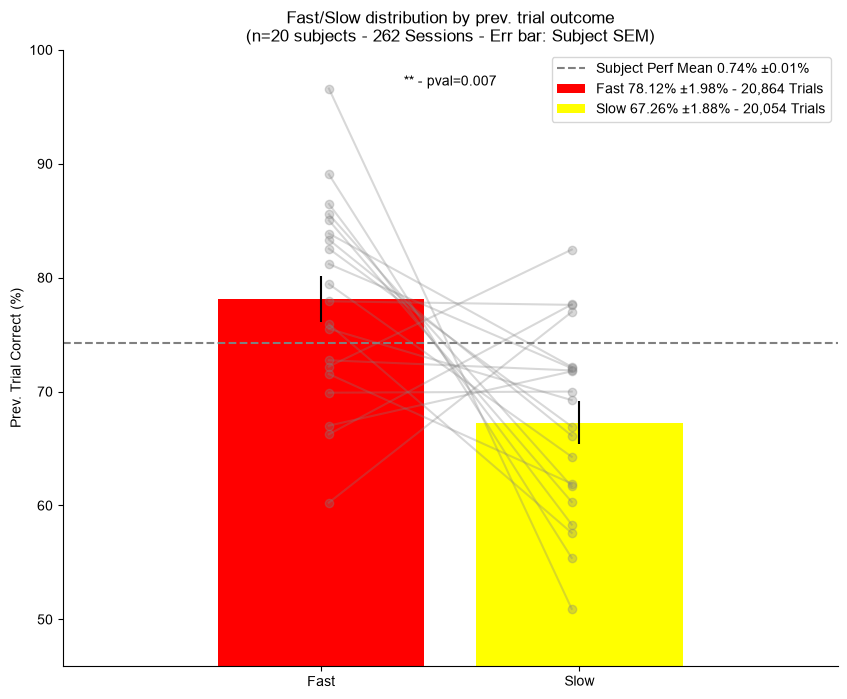

In [36]:
from .figcode.prevoutcomecurquantile import prevOutcomeCurQuantile

prevOutcomeCurQuantile(df_mice,#.groupby("Name").filter(lambda grp: len(grp) > 2_500),
                       save_prefix=save_prefix, save_fig=SAVE_FIGS)
plt.show()

# Stay/Switch probability

In [37]:
from .figcode.stayswitch import staySwitchUpdate

def runStaySwitchUpdate(df, plot_single_subjects=False,
                        plot_combined_subjects=True,
                        save_fig=False, save_prefix=None):
    df = df.copy()
    df = df[df.Stay.notnull()]
    df = df.groupby("Name").filter(lambda grp: len(grp) > 2_500)
    staySwitchUpdate(df, dscrp="Mice", plot_single_subjects=plot_single_subjects,
                     plot_combined_subjects=plot_combined_subjects,
                     save_prefix=save_prefix, save_fig=save_fig)

## Ext. Fig. 3h

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

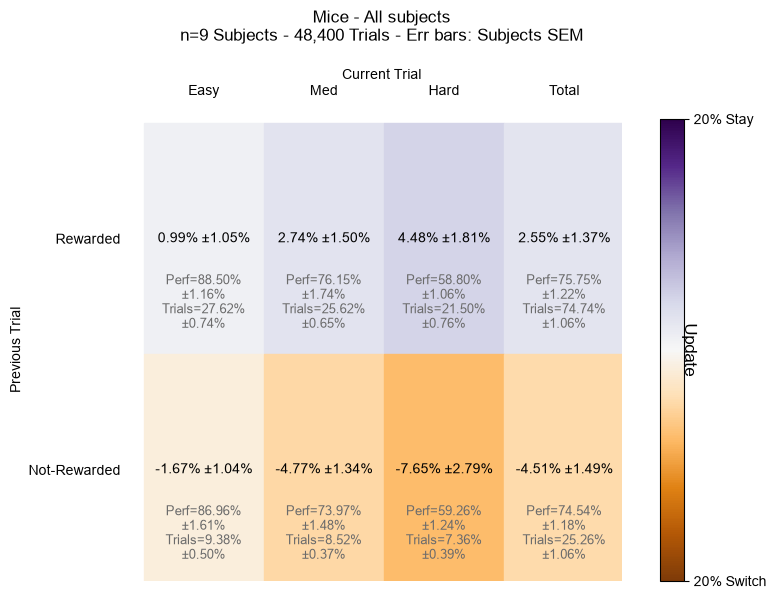

In [38]:
runStaySwitchUpdate(df_mice, plot_single_subjects=False, save_prefix=save_prefix,
                    save_fig=SAVE_FIGS)

## Per subject plots

In [39]:
runStaySwitchUpdate(df_mice, plot_single_subjects=True,
                    plot_combined_subjects=False,
                    save_prefix=save_prefix,
                    save_fig=SAVE_FIGS and not PAPER_FIGURES_ONLY)

Subject: Avgat1 - len: 3169


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

Subject: Avgat3 - len: 2512


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

Subject: GP4-85 - len: 3516


...

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

Subject: vgat-96 - len: 9808


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

Subject: vgatchr2-sk - len: 2991


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rewarded' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.PrevChoiceCorrect == True, "PrevTrial"] = "Rewarded"
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res_grp = indx_groups.apply(_calcGroupUpdate,
C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\stayswitch.py:101: Futur

# Stay/Switch reaction time

## Fig. 1i-right

Paired t-test: -3.21 - p=4.57e-03


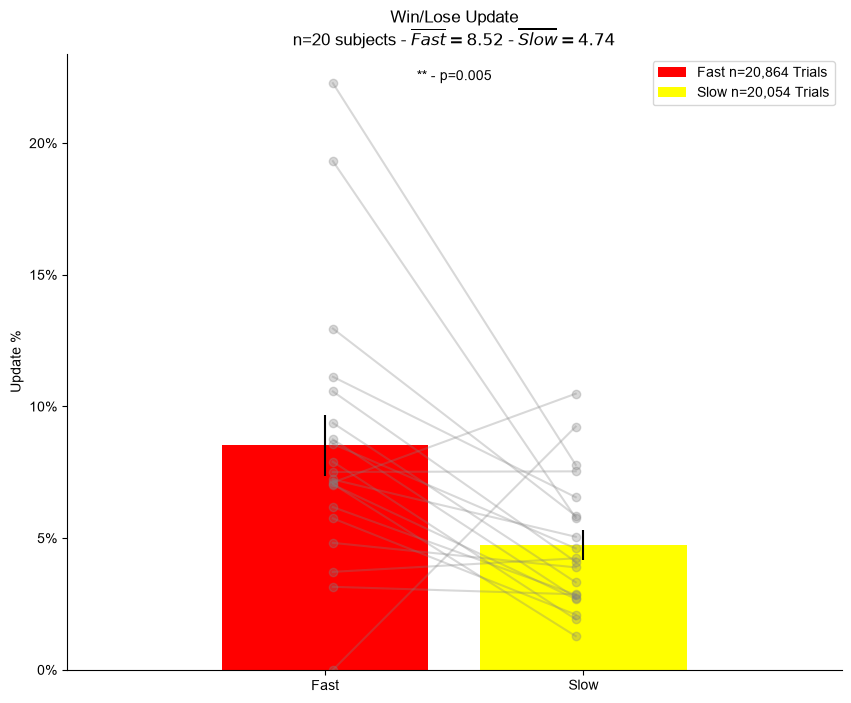

In [40]:
from .behavior.stayswitchupdate import plotQuantileUpdate

_fig, update_result = plotQuantileUpdate(df_mice, save_prefix=save_prefix,
                                         save_figs=SAVE_FIGS)
print(f"Paired t-test: {update_result.statistic:.2f} - "
      f"p={update_result.pvalue:.2e}")

# Stay/Switch over time

## Ext. Fig. 3g

Excluded: ['RDK_WT1', 'RDK_WT6']


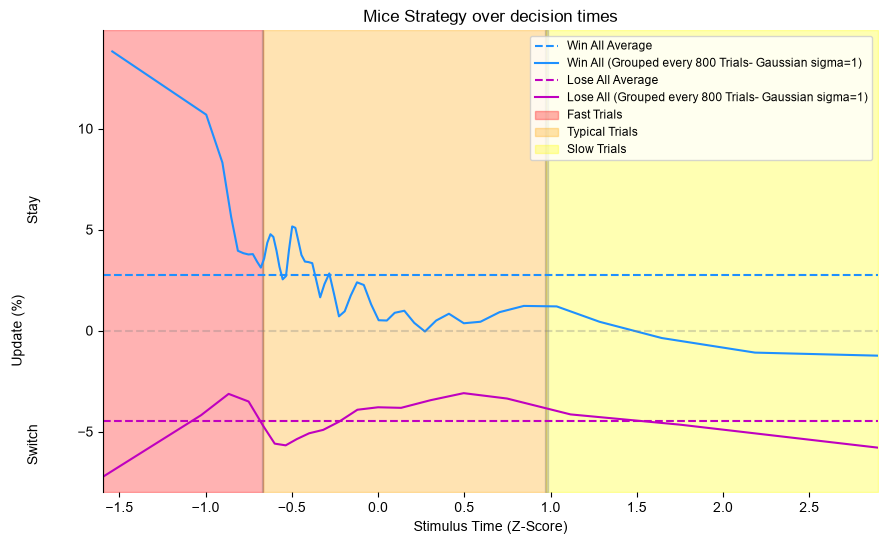

In [41]:
from .behavior.stayswitchupdate import (outlierSubjects,
                                        plotUpdateOverSamplingTime)

# The animals dropped here are derived from the Methods rule -- an unusually
# large fraction of trials below a sampling-time z-score of -1, above the 90th
# percentile of the group -- rather than named.
print("Excluded:", outlierSubjects(df_mice))
_ = plotUpdateOverSamplingTime(df_mice, save_prefix=save_prefix,
                               save_figs=SAVE_FIGS)

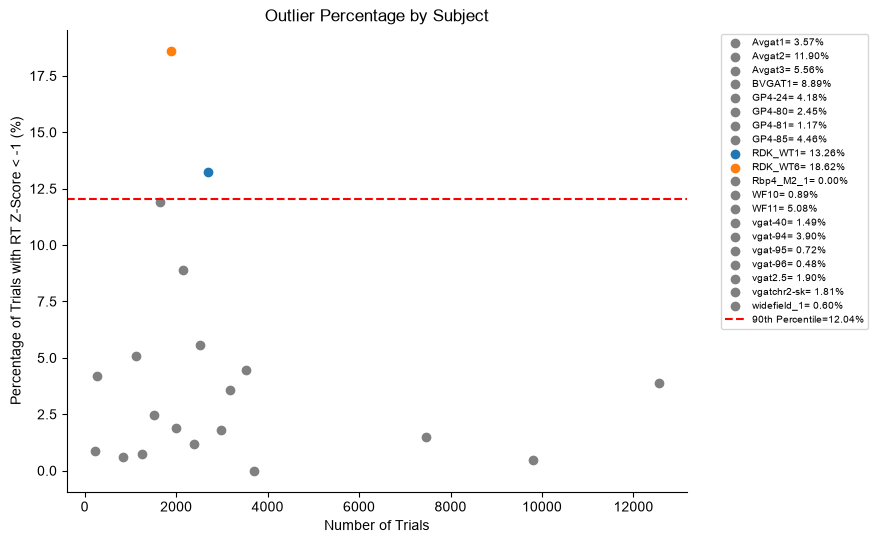

In [42]:
from .behavior.stayswitchupdate import plotOutlierFraction

# The justification for the exclusion above: outlier fraction per animal,
# against the 90th-percentile cut-off.
_ = plotOutlierFraction(df_mice, save_prefix=save_prefix,
                        save_figs=SAVE_FIGS)

# Bias Calculation

# Ext. Fig. 3i

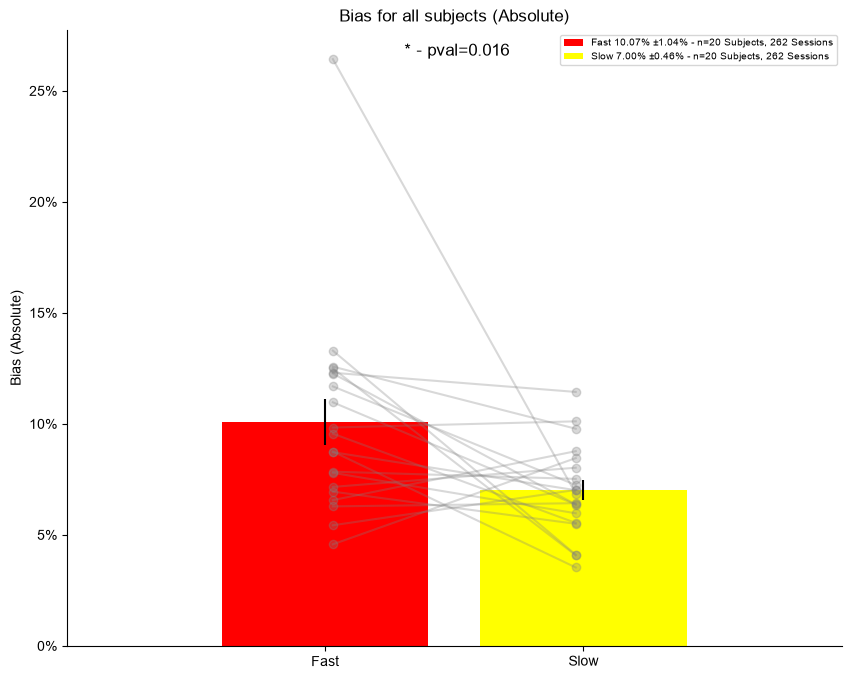

In [43]:
from .behavior.bias import plotBias

plotBias(df_mice,
         as_abs=True, plot_single_subjects=False,
         save_prefix=save_prefix, save_figs=SAVE_FIGS)


# Reward-Rate

## Fig. 1h, Ext. Fig. 3c, d

Number of subjects with RewardRate5 == 1: 20


Group: [0.2, 0.4)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9642304417230971 Pval: 0.6848530372718143 Is Normal: True
Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.8307793723361875 Pval: 0.0025820358843043605 Is Normal: False
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.89937429013565 Pval: 0.04014036650440873 Is Normal: False
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9466879125307001 Pval: 0.3195939921173266 Is Normal: True
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9580888149580522 Pval: 0.5064122522355413 Is Normal: True
Not all groups normal - Proceeding with Kruskal-Wallis Test
Kruskal-Wallis Test - Subject/Group: All Subjects Timeout: All Stat: 23.668095925238845 Pval: 0.0001
Significant differences found - Proceedi

Number of subjects with RewardRate5 == 1: 18


Group: [0.2, 0.4)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9462700403837041 Pval: 0.4329935167910072 Is Normal: True
Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9132860691527415 Pval: 0.09832709854570282 Is Normal: True
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9653953271572076 Pval: 0.7080109640983168 Is Normal: True
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9540767839819375 Pval: 0.4924863639486078 Is Normal: True
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9792488867461464 Pval: 0.9419297742629681 Is Normal: True
All groups normal - Proceeding with ANOVA
One-Way ANOVA - Subject/Group: All Subjects Timeout: All Fstat: 5.432311869739853 Pval: 0.0006189596296279307
Significant differences found - Proceeding with post

Group: [0.4, 0.6)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.902866657046727 Pval: 0.17271854321282437 Is Normal: True
Group: [0.6, 0.8)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9713177132157643 Pval: 0.8770690064064144 Is Normal: True
Group: [0.8, 1.0)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.7936591788479129 Pval: 0.0012375727222965975 Is Normal: False
Group: [1.0, 1.2)
Shapiro-Wilk Test for normality - Subject/Group: All Subjects Timeout: All Stat: 0.9181827597118368 Pval: 0.12003811344887955 Is Normal: True
Not all groups normal - Proceeding with Kruskal-Wallis Test
Kruskal-Wallis Test - Subject/Group: All Subjects Timeout: All Stat: 15.157027116402077 Pval: 0.0017
Significant differences found - Proceeding with post-hoc tests
Post-hoc Dunn's test results:
 			[0.4, 0.6)  [0.6, 0.8)  [0.8, 1.0)  [1.0, 1.2)
[0.4, 0.6)	1.000000	0.700476	0.700476	0.001980
[0.6, 0

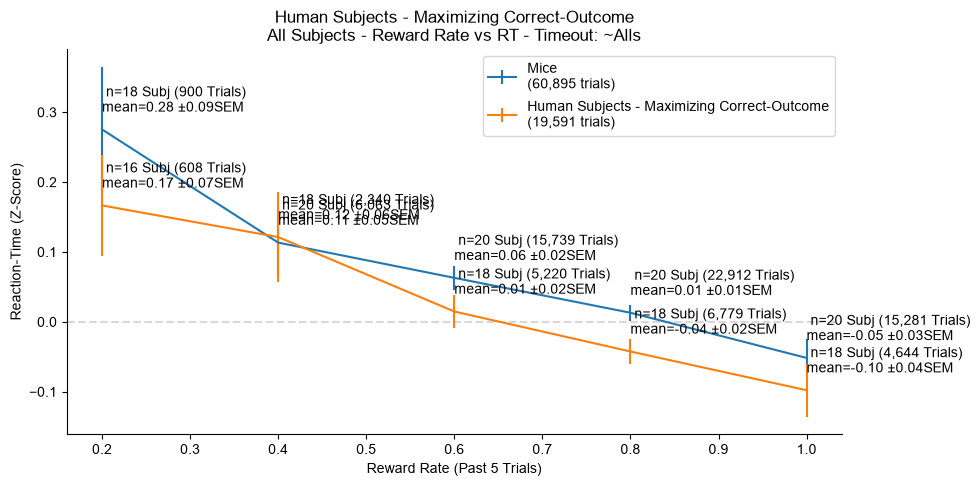

In [44]:
from .behavior.rewardrate import calcAvgRewardRate, loopRewardRateAnalysis

def plotRewardRate(df, min_num_trials, plot_subjects, title, save_figs=False,
                   save_prefix=None, plot_singles_on_all=True, ax=None,
                   ax_all_used_timeout_time=None):
    df = df.copy()
    df["SessId"] = df.Name + "_" + df.Date.astype(str) + "_" + df.SessionNum.astype(str)
    if ax is None:
        ax_was_none = True
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_ylim(bottom=-0.6, top=1.)
        ax_all_used_timeout_time = "All"
    else:
        ax_was_none = False
    loopRewardRateAnalysis(df, min_num_trials=min_num_trials,
                           plot_subjects=plot_subjects, descrp=title,
                           plot_singles_on_all=plot_singles_on_all,
                           save_figs=save_figs, save_prefix=save_prefix,
                           ax_all=ax,
                        #    min_trials_per_sess_rr=10,
                           ax_all_used_timeout_time=ax_all_used_timeout_time)
    if ax_was_none:
        ax.legend()
        plt.show()

def loopRewardRate(df_mice, humans_accuracy_df, humans_max_outcome_df,
                   plot_subjects, save_figs, save_prefix):
    df_mice = df_mice.copy()
    df_mice = df_mice.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    df_mice = calcAvgRewardRate(df_mice)
    df_mice = df_mice.groupby(["Name", "Date", "SessionNum"]).filter(lambda sess_df: sess_df.DV.isnull().sum() == 0)

    humans_accuracy_df = humans_accuracy_df.copy()

    humans_accuracy_df = humans_accuracy_df.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    humans_accuracy_df = calcAvgRewardRate(humans_accuracy_df)
    # Users timeout field is missing. Users had no timeout so assign 0.
    humans_accuracy_df["GUI_TimeOutIncorrectChoice"] = 0
    # Repeat for max outcome humans
    humans_max_outcome_df = humans_max_outcome_df.copy()
    humans_max_outcome_df = humans_max_outcome_df.sort_values(by=["Name", "Date", "SessionNum", "TrialNumber"])
    humans_max_outcome_df = calcAvgRewardRate(humans_max_outcome_df)
    humans_max_outcome_df["GUI_TimeOutIncorrectChoice"] = 0


    COL = "RewardRate5"
    DEFAULT_MIN_NUM_TRIALS = 0
    DEFAULT_ACCURACY_MIN_NUM_TRIALS = 0 # They have less trials compared to speed task and mice

    for df, title in [(df_mice, "Mice"),
                      (humans_max_outcome_df, "Human Subjects - Maximizing Correct-Outcome"),
                      (humans_accuracy_df, "Human Subjects - Accuracy"),
                     ]:
        # df = df[df[COL] != 0] # We have very few points
        num_subjects_in_1st = df[df[COL] == 1].Name.nunique()
        print(f"Number of subjects with {COL} == 1: {num_subjects_in_1st}")
        df = df.groupby(COL).filter(lambda rr_df: rr_df.Name.nunique() >= .75 * num_subjects_in_1st)
        num_rr_bins = len(df[COL].unique())
        # Filter out subjects that do not have all reward-rates bins
        # df = df.groupby("Name").filter(lambda subj_df: subj_df[COL].nunique() == num_rr_bins)
        min_num_trials = DEFAULT_MIN_NUM_TRIALS if "Accuracy" not in title else DEFAULT_ACCURACY_MIN_NUM_TRIALS
        plotRewardRate(df, min_num_trials=min_num_trials,
                       plot_subjects=plot_subjects, title=title,
                       save_figs=save_figs, save_prefix=save_prefix)


    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
    for df, title in [(df_mice, "Mice"),
                           (humans_max_outcome_df, "Human Subjects - Maximizing Correct-Outcome"),
                          #   (humans_accuracy_df, "Human Subjects - Accuracy"),
                      ]:
        # df = df[df[COL] != 0] # We have very few points
        num_subjects_in_1st = df[df[COL] == 1].Name.nunique()
        # print(f"Number of subjects with {COL} == 1: {num_subjects_in_1st}")
        df = df.groupby(COL).filter(lambda rr_df: rr_df.Name.nunique() >= .75 * num_subjects_in_1st)
        # display(df.groupby(COL).Name.nunique())
        # print(f"Remaining reward-rates: ", df[COL].unique())
        # return
        min_num_trials = DEFAULT_MIN_NUM_TRIALS if "Accuracy" not in title else DEFAULT_ACCURACY_MIN_NUM_TRIALS
        # Draws into the shared axis only -- this cell saves the combined
        # figure itself below. Saving here would write the half-built figure
        # and close it before that.
        plotRewardRate(df, min_num_trials=min_num_trials,
                       plot_subjects=False, title=title,
                       ax=ax, ax_all_used_timeout_time="All",
                       plot_singles_on_all=False)
    ax.legend()
    if save_figs:
        plt.savefig(f"{save_prefix}/reward_rate5.svg", bbox_inches="tight")
    plt.show()

loopRewardRate(df_mice=df_mice, humans_accuracy_df=humans_accuracy_df,
               humans_max_outcome_df=humans_max_outcome_df, plot_subjects=False,
               save_prefix=save_prefix, save_figs=SAVE_FIGS)

# Behavior Parameters Variance Explained

In [45]:
from .behavior.varexplained import (loopSubjects, plotVarianceExplained,
                                    totalVarianceExplained)

var_exp_df = loopSubjects(df_mice)
print(f"Total variance explained: {totalVarianceExplained(var_exp_df):.1f}%")
print(f"Condition numbers: {var_exp_df.cond_no.min():.1f}"
      f"-{var_exp_df.cond_no.max():.1f}")
var_exp_df

Total variance explained: 101.9%
Condition numbers: 14.3-22.2


,Name,DVabs,PrevOutcomeCount,ChoiceLeft,Stay,cond_no,n_trials
0,Avgat1,17.206627,42.711503,2.113021,39.745997,15.471573,2786
1,Avgat3,1.524838,55.466023,28.045231,13.980771,14.442032,2472
2,GP4-85,51.899956,8.528662,2.737700,41.330391,22.241207,3442
3,RDK_WT1,5.379824,82.707865,8.262809,2.494118,18.504097,2652
4,Rbp4_M2_1,23.235142,9.942270,34.987132,36.827824,14.907465,3604
5,vgat-40,56.567043,36.059528,0.058663,10.179665,16.387414,7298
6,vgat-94,15.275601,20.834844,42.855128,22.522191,14.313625,12301
7,vgat-96,49.969355,18.947627,31.004959,0.046315,16.380282,9579
8,vgatchr2-sk,23.292781,34.084734,39.135580,6.722750,19.274618,2916


## Fig. 2A

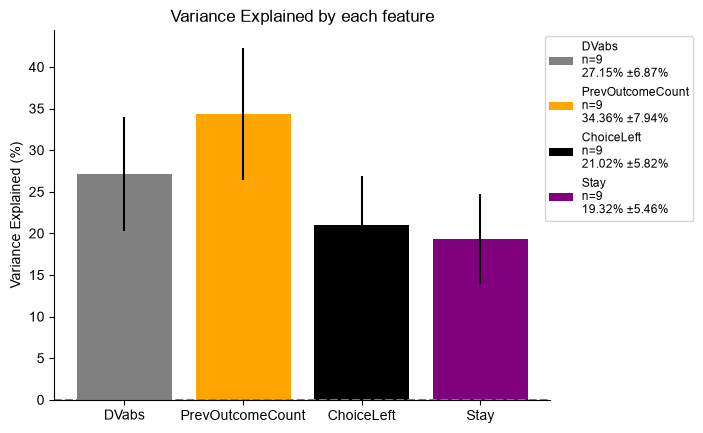

In [46]:
_ = plotVarianceExplained(var_exp_df, save_prefix=save_prefix,
                          save_figs=SAVE_FIGS)

# Fast/Slow Psychometric

## Fig. 1e


Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.10000000000000009: t=-1.6224, p=0.1287, p_holm=0.1287, reject=False
  dv=0.21367895514681806: t=-5.2070, p=0.0002194, p_holm=0.0006581, reject=True
  dv=0.5278008899038497: t=-3.7590, p=0.001328, p_holm=0.002657, reject=True
  dv=0.9942647173059079: t=-4.7473, p=0.0001402, p_holm=0.0005606, reject=True


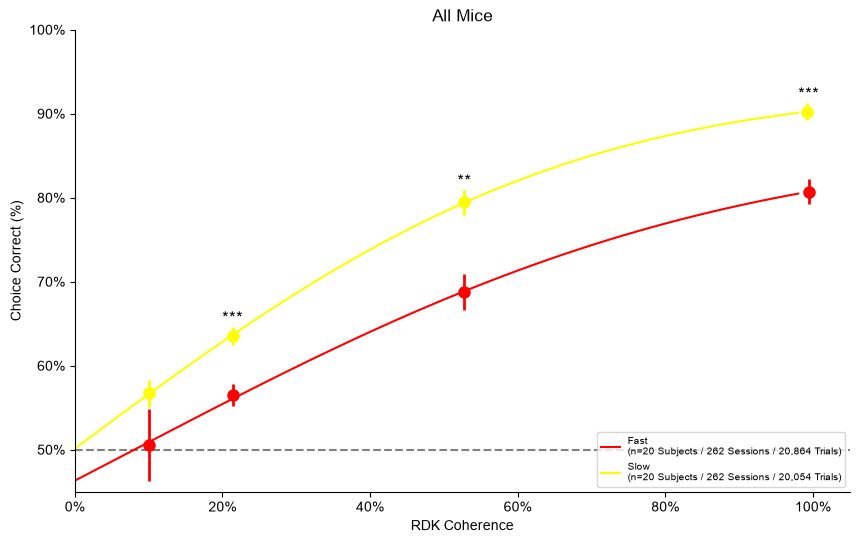

In [47]:
from .figcode.psychometric import slowFastPsych

slowFastPsych(df=df_mice, is_human_subject=False,
              combine_sides=True, plot_typical=False, save_fp=f"{save_prefix}/psych_mice/",
              plot_single_subjects=False, subject_plot_points=False,
              save_figs=SAVE_FIGS)


## Ext. Fig f

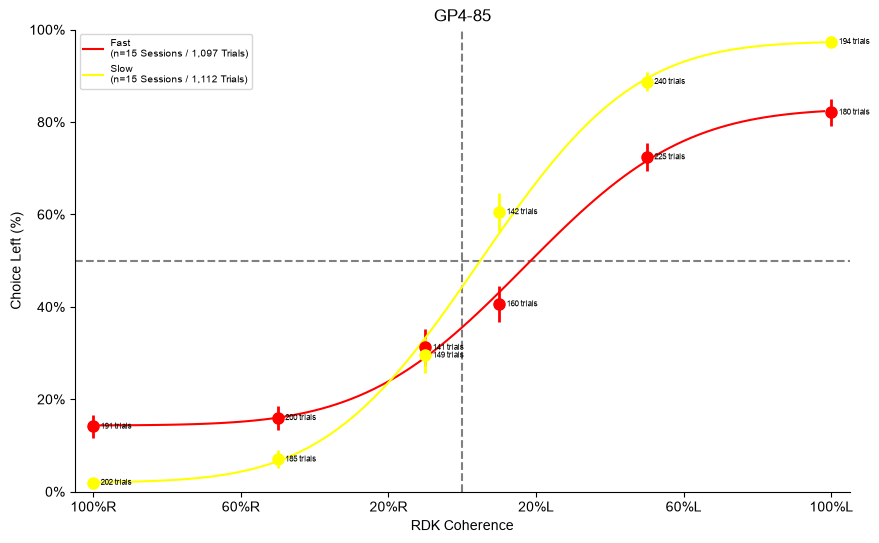

In [48]:
from .figcode.psychometric import slowFastPsych

slowFastPsych(df=df_mice[df_mice.Name == "GP4-85"], is_human_subject=False,
              combine_sides=False, plot_typical=False, save_fp=f"{save_prefix}/psych_mice/",
              plot_single_subjects=True, plot_combined_subjects=False,
              subject_plot_points=True, save_figs=SAVE_FIGS)


## For humans

## Fig. 1f


Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.01: t=-0.3049, p=0.7642, p_holm=1, reject=False
  dv=0.032678697893234396: t=0.9574, p=0.3518, p_holm=1, reject=False
  dv=0.0785595492916538: t=0.8276, p=0.4194, p_holm=1, reject=False
  dv=0.1389577439762197: t=0.1518, p=0.8811, p_holm=1, reject=False
  dv=0.3297246590087789: t=-3.6997, p=0.001779, p_holm=0.01067, reject=True
  dv=0.7518866040245903: t=-3.6090, p=0.002166, p_holm=0.01083, reject=True


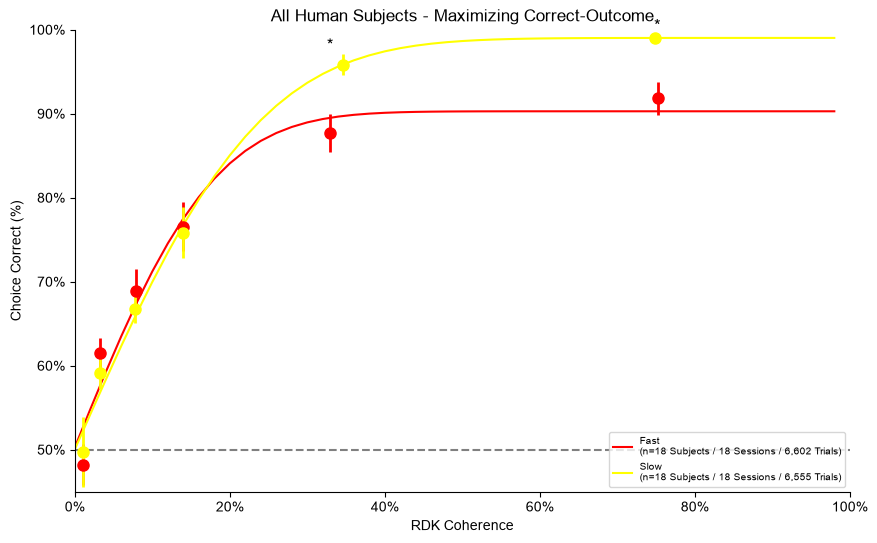

In [49]:
slowFastPsych(humans_max_outcome_df, is_human_subject=True, title_suffix="Maximizing Correct-Outcome",
              combine_sides=True, plot_typical=False,
              plot_single_subjects=False, subject_plot_points=False,
              save_fp=f"{save_prefix}/psych_human/Maximizing Correct-Outcome_",
              save_figs=SAVE_FIGS)

## Ext. Fig. 3i

C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\figcode\psychofit\psychofit.py:312: RuntimeWarning: divide by zero encountered in divide
  return gamma + (1 - 2 * gamma) * (erf((xx - bias) / slope) + 1) / 2



Fast vs Slow per-dv paired tests (Holm-FWER corrected):
  dv=0.010000000000000002: t=1.5408, p=0.1619, p_holm=0.4858, reject=False
  dv=0.03238064537336668: t=2.9879, p=0.01525, p_holm=0.06101, reject=False
  dv=0.0779480056664964: t=3.6170, p=0.002802, p_holm=0.01681, reject=True
  dv=0.13942884245111212: t=3.1696, p=0.006347, p_holm=0.03174, reject=True
  dv=0.3200809658396029: t=0.0984, p=0.9228, p_holm=0.9228, reject=False
  dv=0.7679856479627012: t=1.3597, p=0.1928, p_holm=0.4858, reject=False


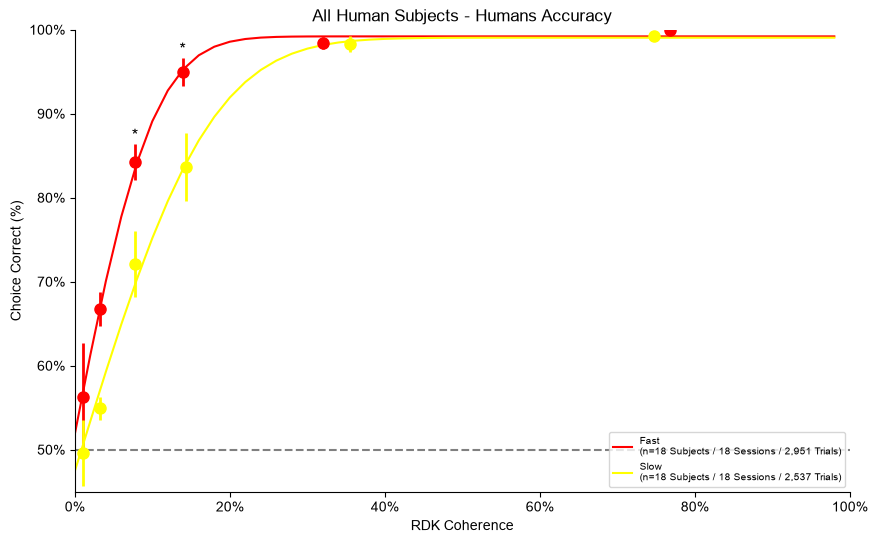

In [50]:
slowFastPsych(humans_accuracy_df, is_human_subject=True, title_suffix="Humans Accuracy",
              combine_sides=True, plot_typical=False,
              plot_single_subjects=False, subject_plot_points=False,
              save_fp=f"{save_prefix}/psych_human/Humans Accuracy",
              save_figs=SAVE_FIGS)

# Chronometry

## Ext. Fig. 1c-right

Subject: All Animals
Min sampling points: [np.float64(0.3), np.float64(0.6), np.float64(0.8999999999999999), np.float64(1.0), np.float64(1.2), np.float64(1.5)]


C:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\behavior\util\splitdata.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dv_rng, dv_df in df.groupby(pd.cut(DV, bins, include_lowest=True)):


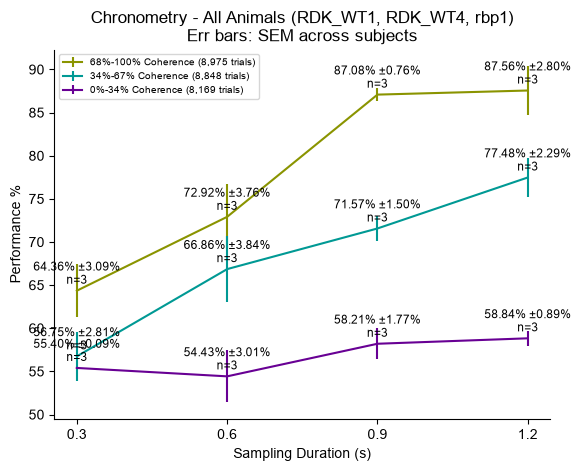

In [51]:
from .behavior.chronometry import chronometry, Plots, GroupBy
from .common.definitions import ExpType

def runChrono(df, save_prefix, save_figs):
    df = df[df.ChoiceCorrect.notnull()]
    df = df.groupby("Name").filter(lambda grp: len(grp) > 2_500)
    chronometry(df,#.query("Name == 'RDK_WT4'"),
                plots=Plots.Chronometry,# | Plots.ChronoPsych,
                plot_all_animals=True, plot_single_animals=False,
                min_easiest_perf=75, min_num_sampling_pts=3,
                # Try without fixed points and you'll get the same
                # results but with extra points in the middle
                min_sampling_pts=[0.3, 0.6, 0.9, 1.2],
                save_figs=save_figs,
                exp_type=ExpType.RDK, grpby=GroupBy.Difficulty,
                save_prefix=save_prefix)

runChrono(df_chrono, save_prefix, save_figs=SAVE_FIGS)

# DV_str distribution

DV
100.0    95.030038
90.0      2.978616
70.0      1.554426
80.0      0.436920
Name: count, dtype: float64

DV
50.0    63.450775
60.0    31.814845
40.0     4.124232
Name: count, dtype: float64

DV
20.0    46.925584
10.0    43.318049
30.0     8.789570
0.0      0.966797
Name: count, dtype: float64

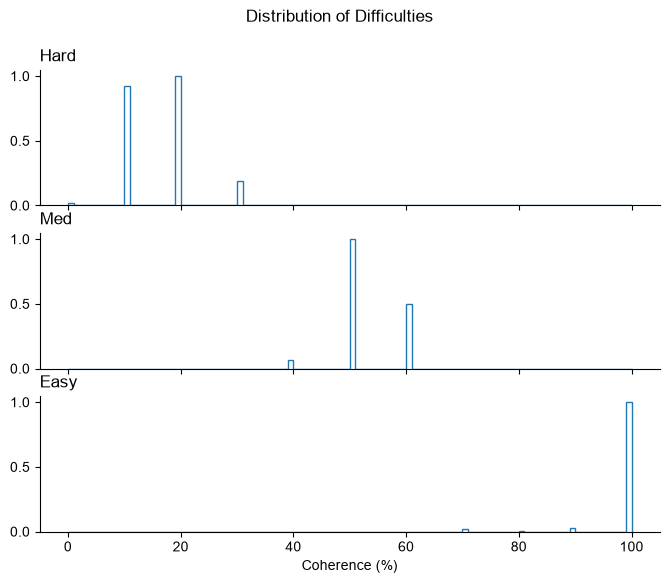

In [52]:
def plotDVstrDist(df, save_figs=SAVE_FIGS):
    fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    fig.suptitle("Distribution of Difficulties")
    axs = axs[::-1]
    for y_idx, dv_str in enumerate(["Easy", "Med", "Hard"]):
        dv_str_cohr = df[df.DVstr == dv_str].DV.abs()*100
        # display(dv_str_dv.describe())
        ax = axs[y_idx]
        # Make a violin plot
        rng = np.arange(0, 101, 1)
        vals, edges = np.histogram(dv_str_cohr, bins=rng)
        vals = vals.astype(float)/vals.max()
        ax.stairs(vals, edges, label=f"n={len(dv_str_cohr):,}")
        ax.set_title(dv_str, loc="left")
        if y_idx == 0:
            ax.set_xlabel("Coherence (%)")
        # print(f"{dv_str} Coherence Distribution (%):")
        display(dv_str_cohr.value_counts()*100/len(dv_str_cohr))
    for ax in axs:
        # ax.set_yticks([0, 1, 2])
        # ax.set_yticklabels(["Easy", "Med", "Hard"])
        ax.spines[["top", "right"]].set_visible(False)
    if save_figs:
        fig.savefig(f"{save_prefix}/dvstr_distribution.svg",
                    bbox_inches="tight")
    plt.show()

plotDVstrDist(df_mice, save_figs=SAVE_FIGS)

In [53]:
_grps = df_mice.groupby(["Name", "Date"]) # we never collect more than one session per day, it mainly if MATLAB crashes
print("Mean group size:", _grps.size().mean(), "- Std:", _grps.size().sem())
print("Mean group min:", _grps.size().min(), "- Max:", _grps.size().max())
print("group .1 quantile:", _grps.size().quantile(0.1), "- .9 quantile:", _grps.size().quantile(0.9))

Mean group size: 247.86770428015564 - Std: 4.593192864295766
Mean group min: 33 - Max: 485
group .1 quantile: 167.2 - .9 quantile: 344.4


In [54]:
100*df_mice.GUI_TimeOutIncorrectChoice.value_counts()/len(df_mice)

GUI_TimeOutIncorrectChoice
4.0    54.252614
0.0    22.644501
5.0    15.550532
2.0     6.583781
3.0     0.759788
1.0     0.199366
6.0     0.009419
Name: count, dtype: float64

# Freely moving mice behavior

In [55]:
# from ...behavior.definitions import MouseState, ExperimentType

import numpy as np
from enum import Enum, IntEnum
class _EnumShortStrMixin:
  def __str__(self):
    return self.name

  def __format__(self, fmt):
    return self.__str__()

class FloatEnumShortStr(_EnumShortStrMixin, float, Enum):
  pass

class IntEnumShortStr(_EnumShortStrMixin, IntEnum):
  pass

class ExperimentType(IntEnumShortStr):
  Auditory = 1
  LightIntensity = 2
  GratingOrientation = 3
  RDK = 4
  SoundIntensity = 5
  NoStimulus = 6

class MouseState(FloatEnumShortStr):
  Unknown = np.nan
  FreelyMoving = 1
  HeadFixed = 2
class StimAfterPokeOut(IntEnumShortStr):
  NotUsed = 0
  UntilFeedbackStart = 1
  UntilFeedbackEnd = 2
  UntilEndOfTrial = 3
  NotUsedMatlab = 4

class MinSamplingType(FloatEnumShortStr):
  Unknown = np.nan
  FixMin = 1
  AutoIncr = 2
  RandBetMinMax_DefIsMax = 3
  RandNumIntervalsMinMax_DefIsMax = 4



## Ext. Fig. 1d-right

LightIntensityFreelyMoving
LightIntensityHeadFixed
RDKHeadFixed


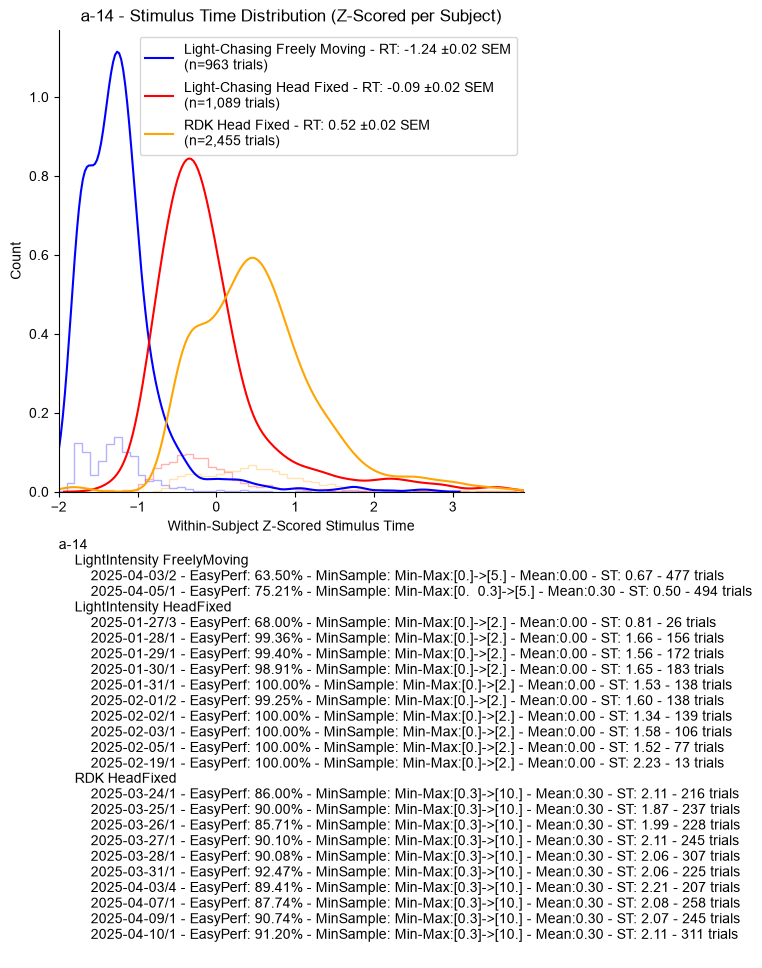

In [56]:
from .behavior.stkde import plotFMHFSubjects

# One stimulus-time figure per accepted freely-moving / head-fixed mouse: a
# faint normalized histogram plus a KDE per experiment-type x mouse-state
# group. The session-collection pass (RDK easy-performance filter, 4.9s cap,
# last 10 sessions, subject acceptance) lives in behavior/stkde.py.
# ZSCORE_FMHF False -> raw seconds. True -> all of that mouse's plotted groups
# are pooled and z-scored together, saved as *_zscored.svg.
ZSCORE_FMHF = True

_ = plotFMHFSubjects(lc_hf_combined_df[lc_hf_combined_df.Name == "a-14"],
                     min_sess_per_state=1, zscore=ZSCORE_FMHF,
                     save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Per human-subject sampling time (seconds)

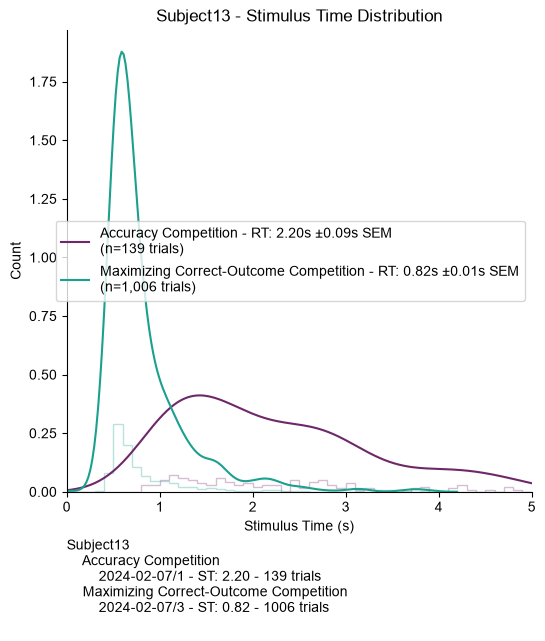

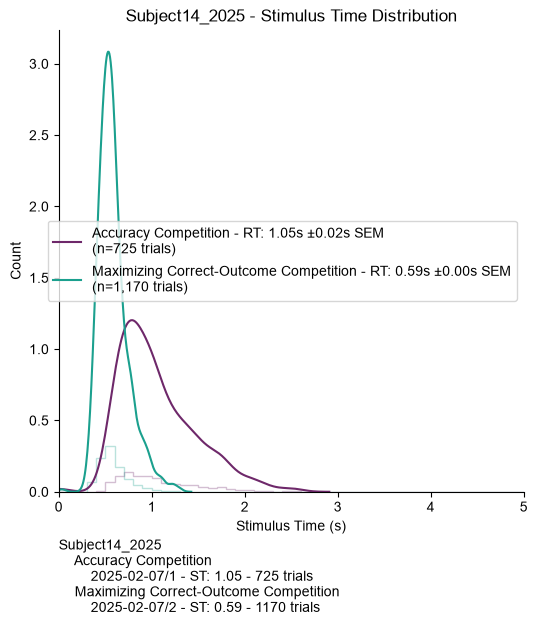

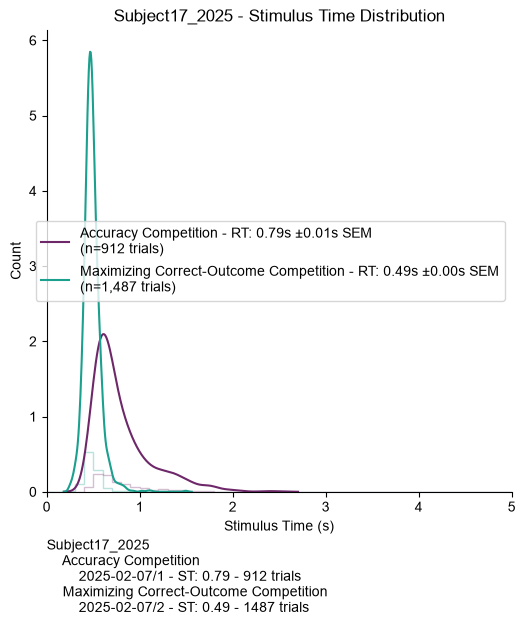

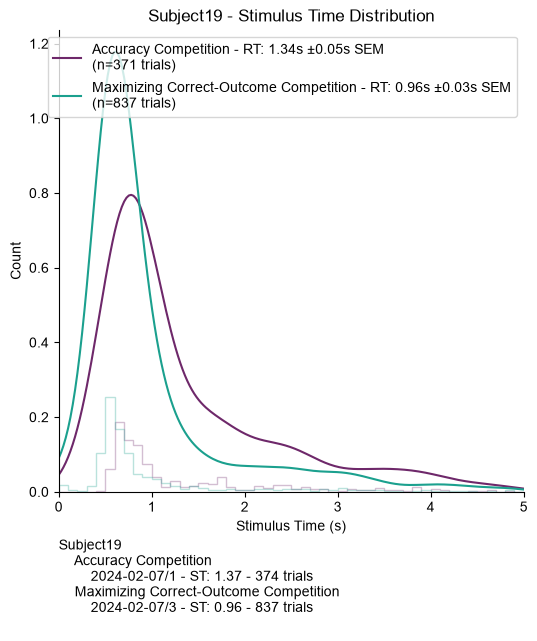

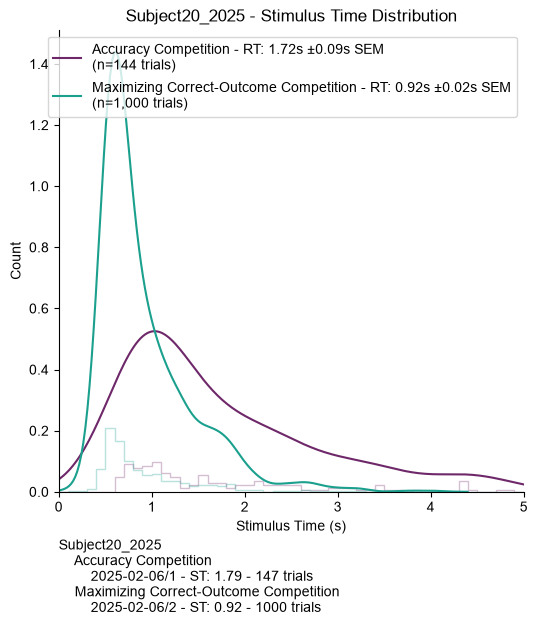

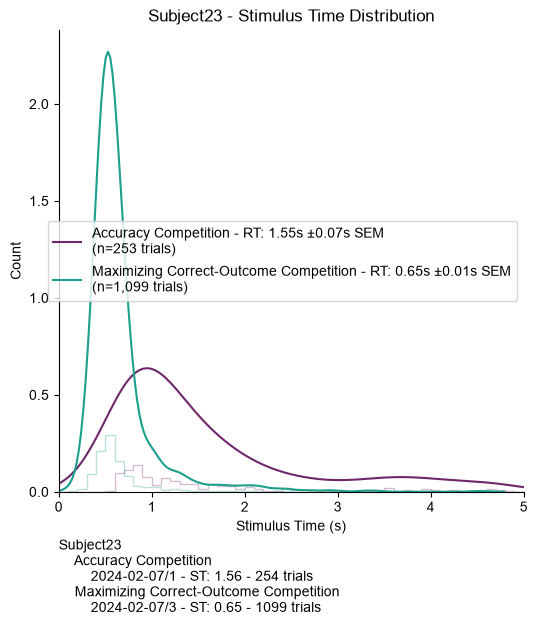

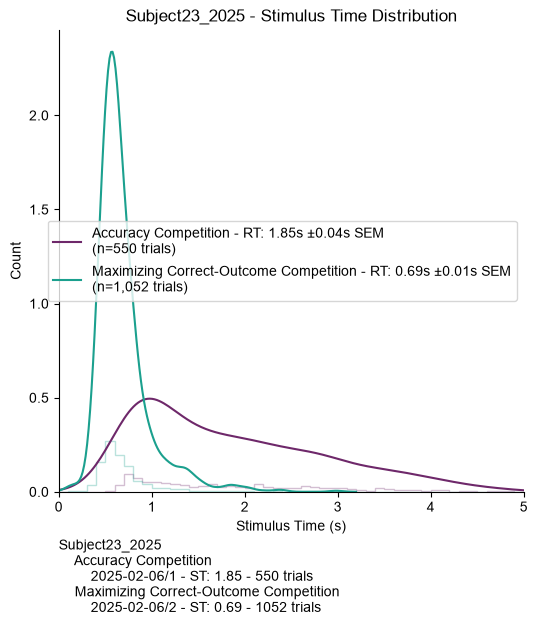

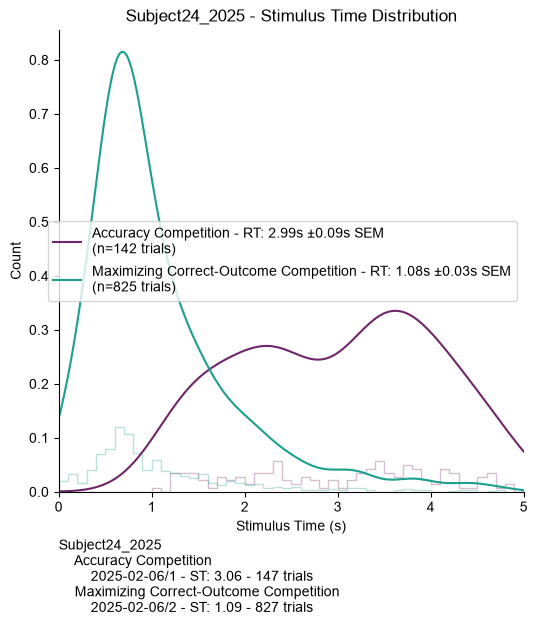

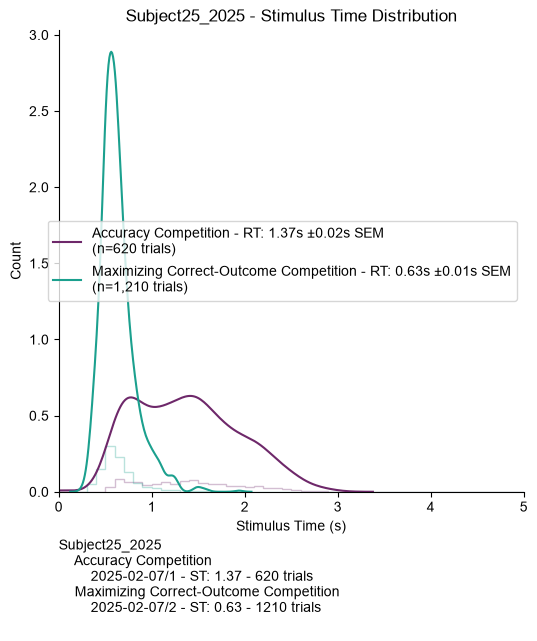

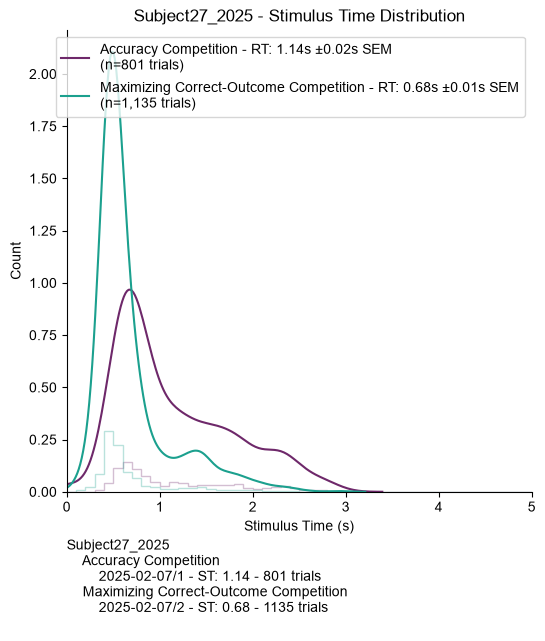

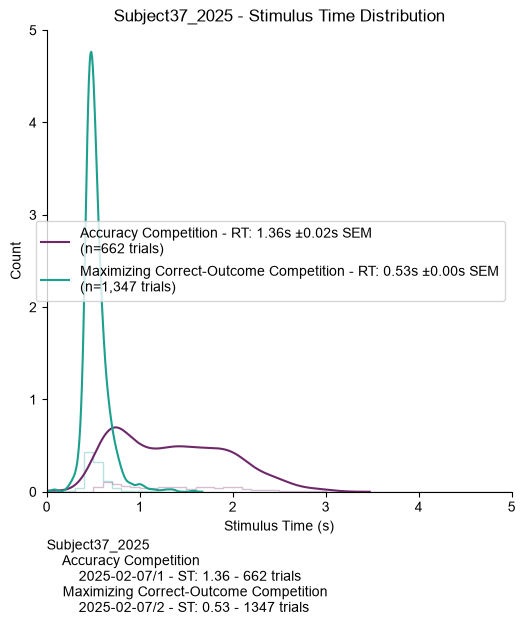

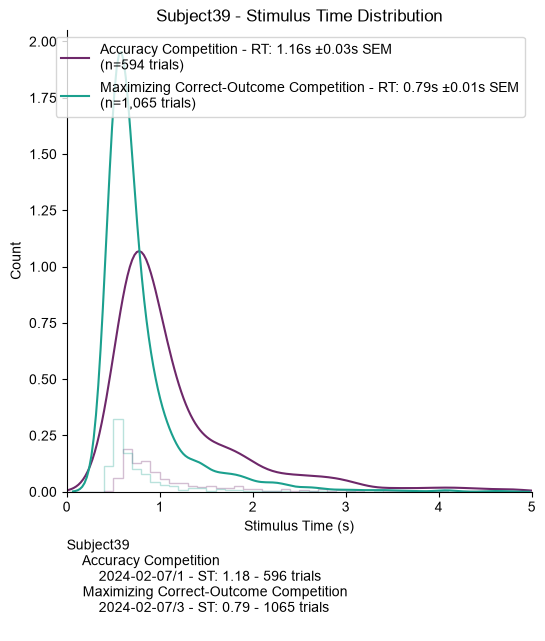

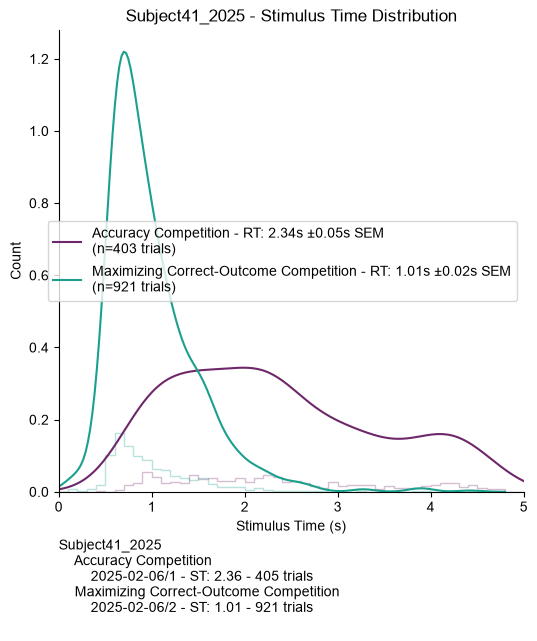

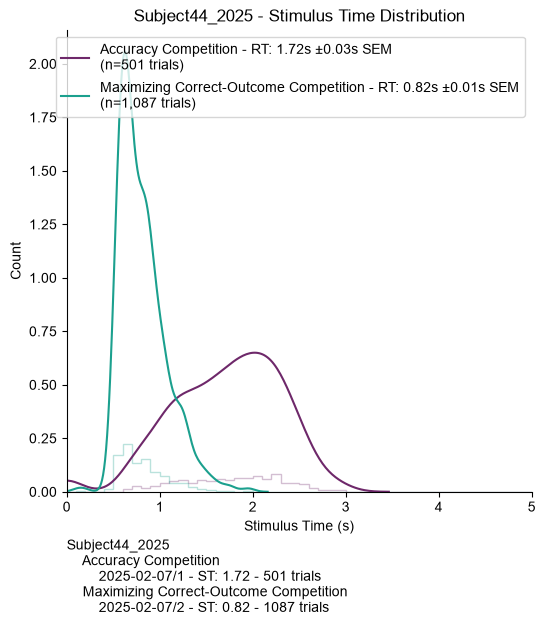

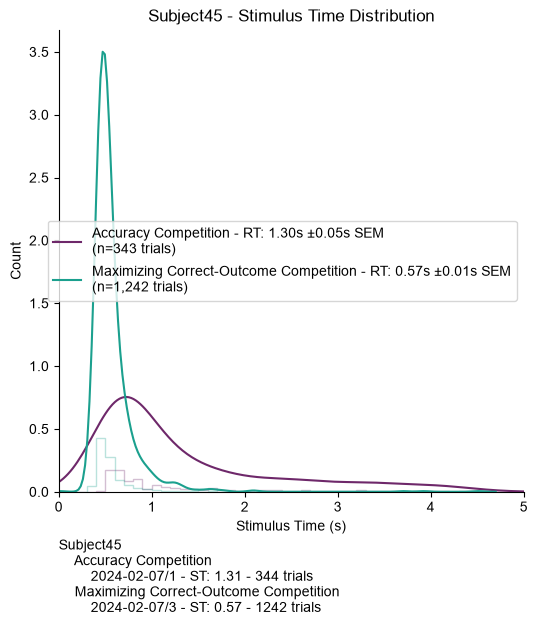

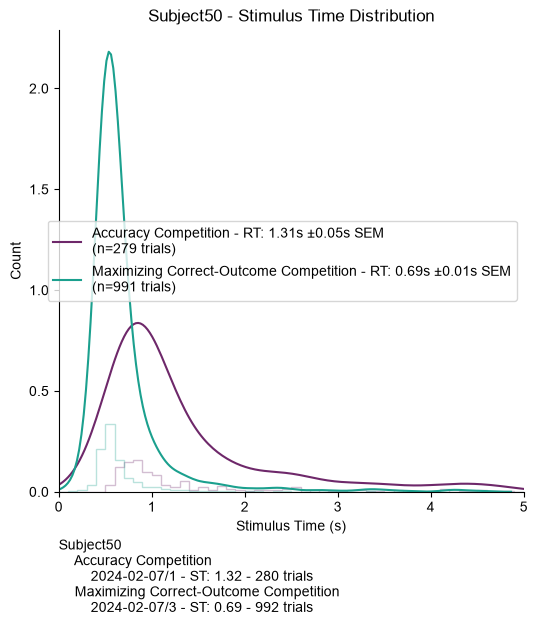

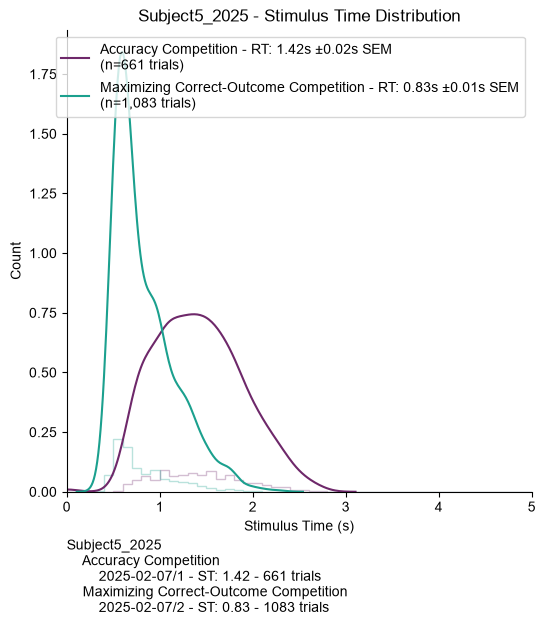

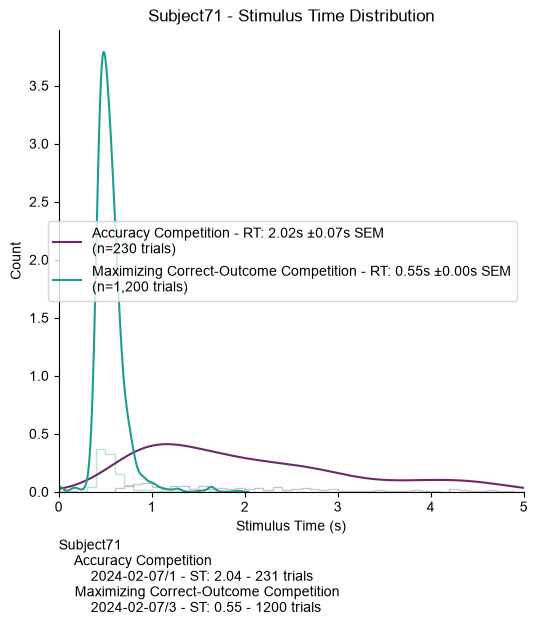

In [57]:
from .behavior.stkde import plotHumanSubjects

# The human counterpart of the figure above: one figure per subject with the
# raw (seconds, not z-scored) sampling time of both experiment types, saved
# under <save_prefix>/humans_st/stimulus_time_<subject>.svg. Pass subjects=[...]
# to restrict it to a few subjects.
HUMAN_ST_COLORS = {"Accuracy Competition": COLOR_ACCURACY,
                   "Maximizing Correct-Outcome Competition": COLOR_MAX_OUTCOME}

_ = plotHumanSubjects(df_users, colors=HUMAN_ST_COLORS,
                      save_prefix=save_prefix, save_figs=SAVE_FIGS)

## Mouse & human sampling time together

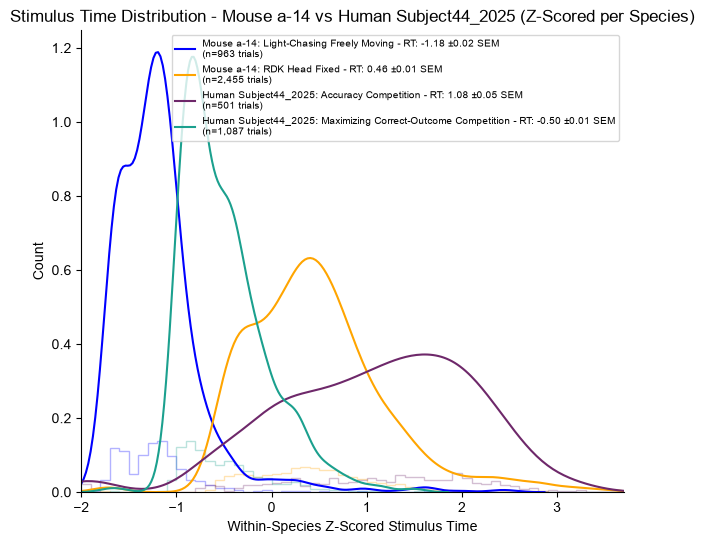

In [58]:
from .behavior.stkde import COMBINED_MOUSE_GROUPS, plotMouseHumanSTKde

# One mouse and one human subject on the same axes. Only the
# COMBINED_MOUSE_GROUPS subset of the mouse's curves is drawn, against the
# human's two experiment types.
# ZSCORE False -> raw seconds. True -> each species is z-scored against its own
# pool (the mouse's plotted groups pooled together, the human's experiment types
# pooled together) and the figure saves under a separate *_zscored.svg name.
MOUSE_SUBJECT = "a-14"
# HUMAN_SUBJECT = "Subject50"
HUMAN_SUBJECT = "Subject44_2025"
ZSCORE = True

_ = plotMouseHumanSTKde(lc_hf_combined_df, df_users,
                        mouse_subject=MOUSE_SUBJECT,
                        human_subject=HUMAN_SUBJECT,
                        mouse_groups=COMBINED_MOUSE_GROUPS,
                        human_colors=HUMAN_ST_COLORS, zscore=ZSCORE,
                        save_prefix=save_prefix, save_figs=SAVE_FIGS)

## All RDK mice vs all human speed-context trials

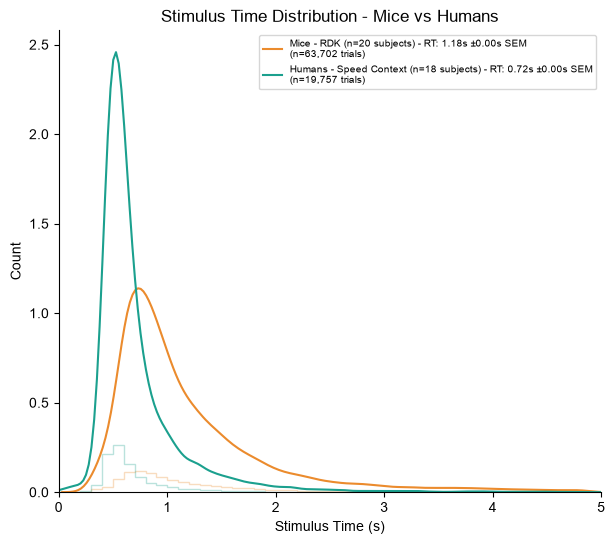

In [59]:
from .behavior.stkde import (HUMAN_SPEED_LABEL, MICE_POOL_LABEL,
                             plotMiceVsHumansST)

# Two KDEs of the real (seconds, never z-scored) sampling time: every RDK mouse
# of df_mice pooled into one curve, and every human speed-context trial (the
# "Competition" / maximizing-correct-outcome sessions) pooled into the other.
POOLED_COLORS = {MICE_POOL_LABEL: COLOR_MICE,
                 HUMAN_SPEED_LABEL: COLOR_MAX_OUTCOME}

_ = plotMiceVsHumansST(df_mice, df_users, colors=POOLED_COLORS,
                       save_prefix=save_prefix, save_figs=SAVE_FIGS)

# Reward-optimal sampling time

## Fig. 2B

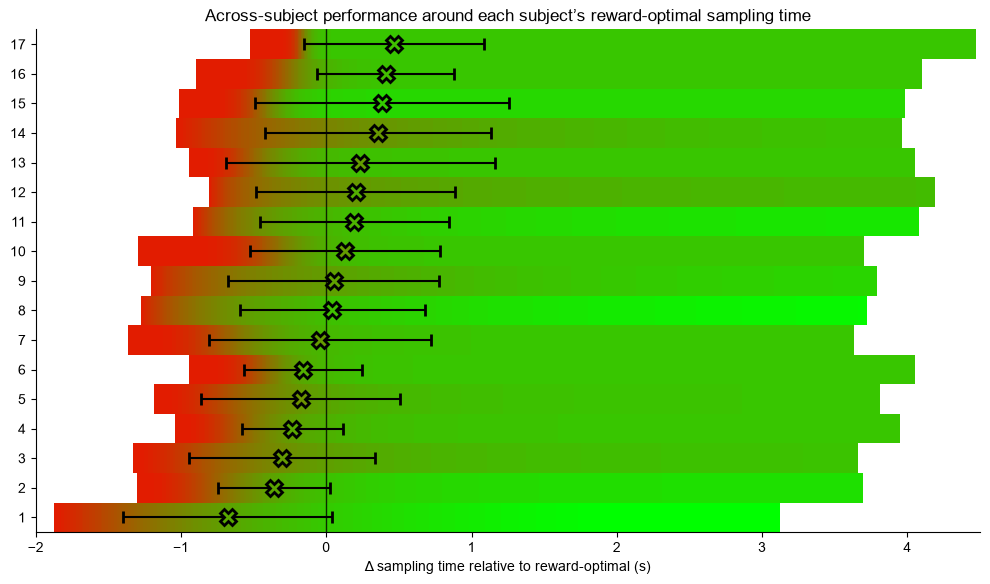

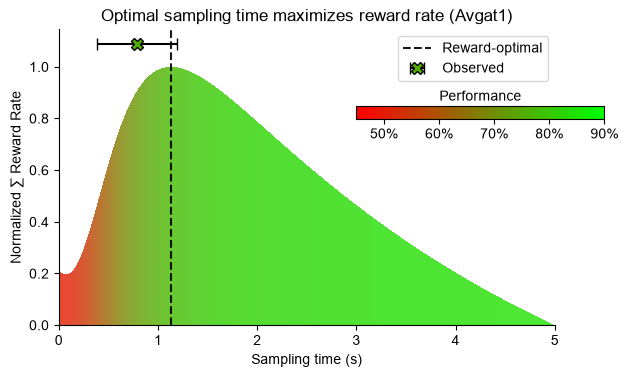

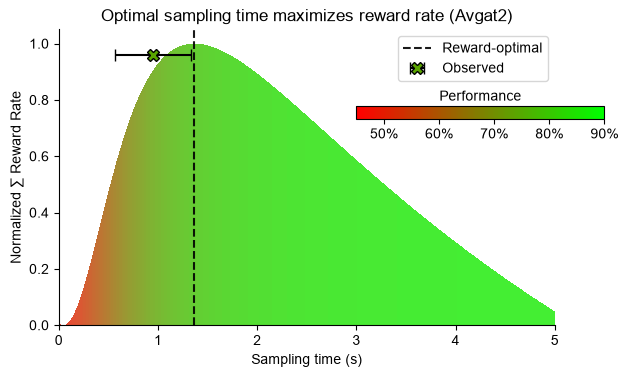

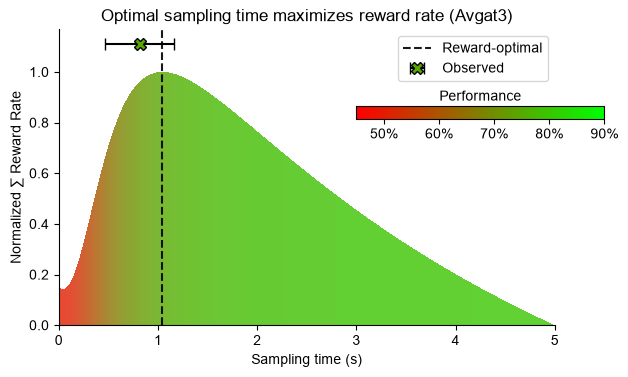

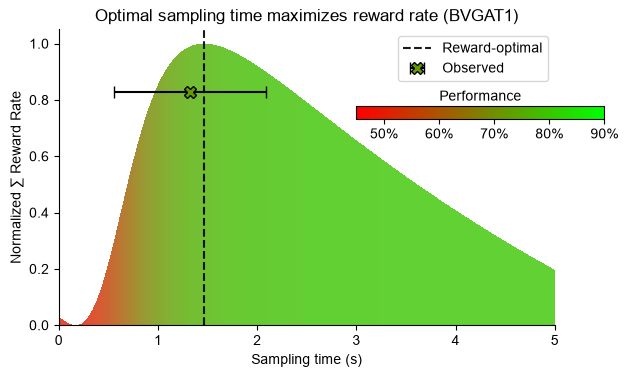

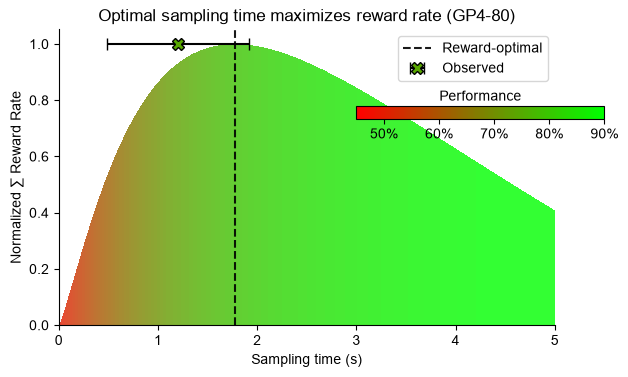

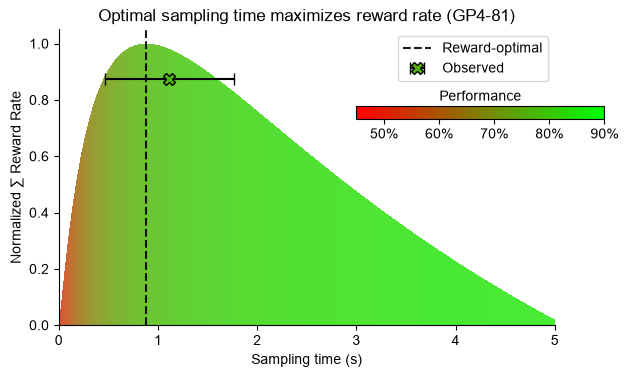

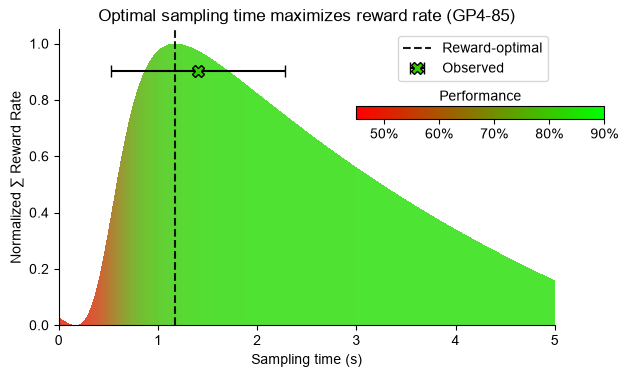

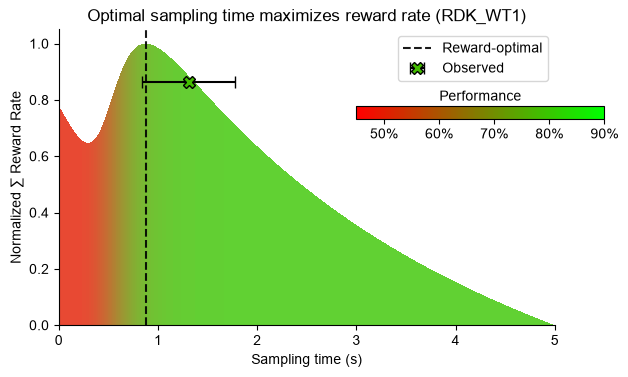

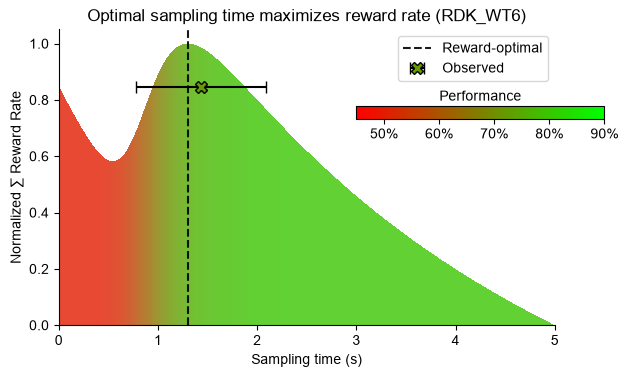

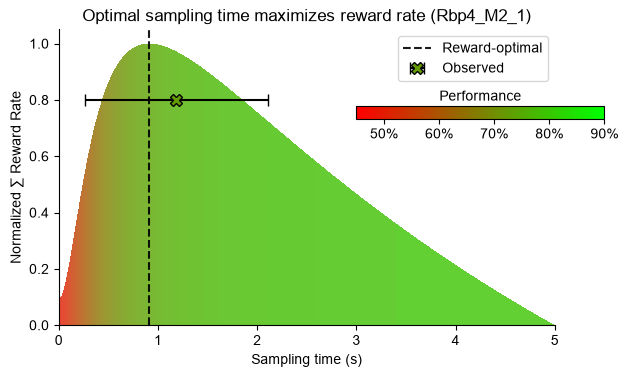

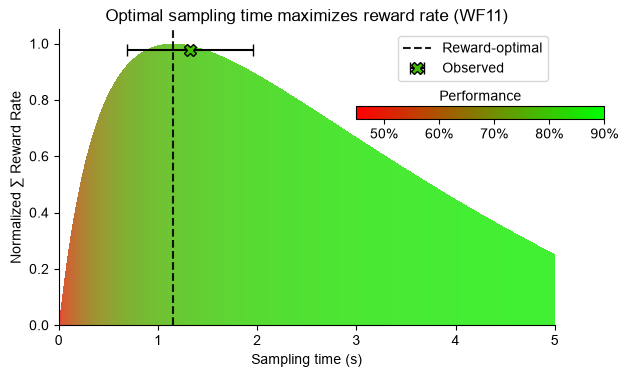

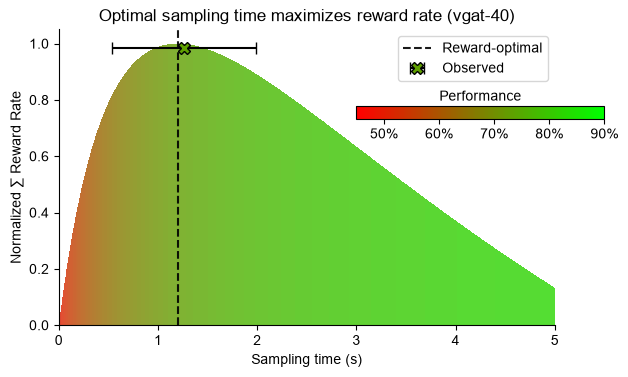

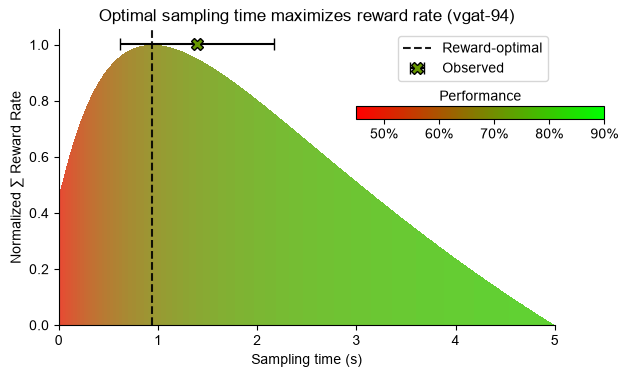

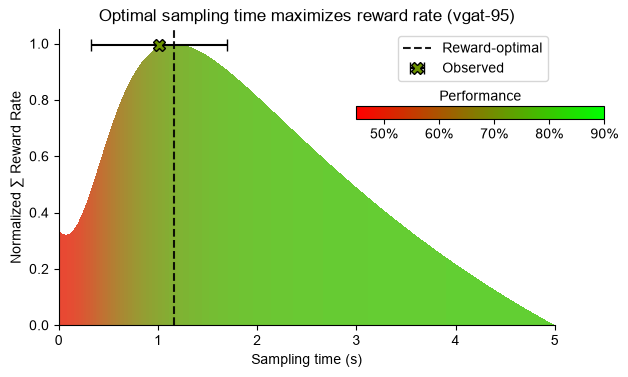

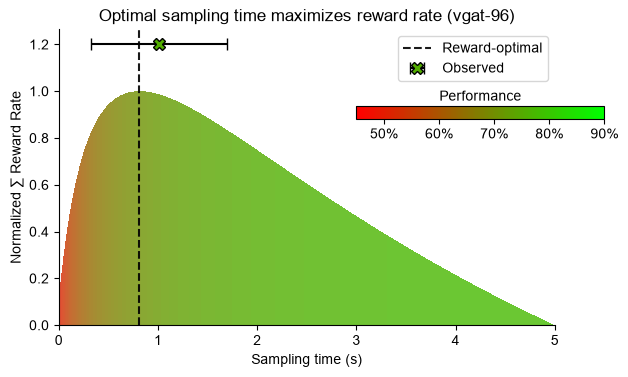

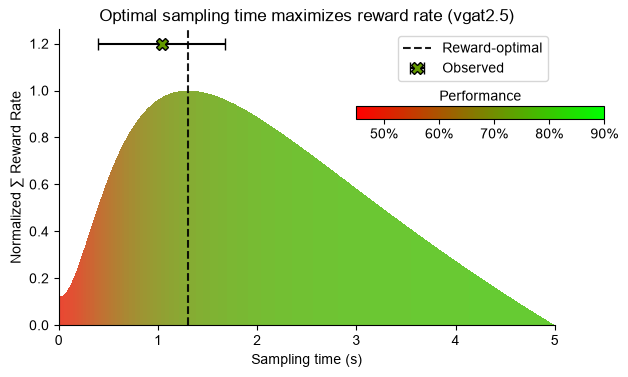

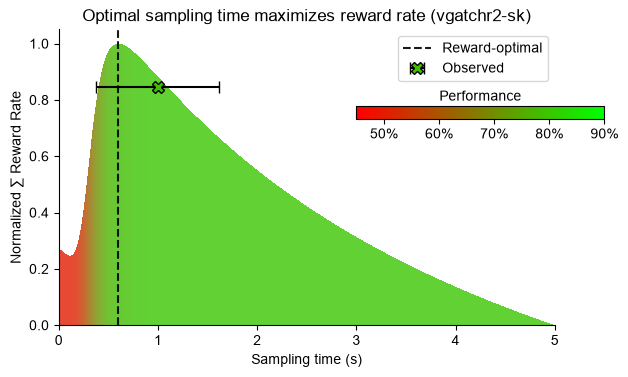

In [60]:
from .behavior.optimalsampling import (POPULATION_SMOOTH_WINDOW,
                                       SUBJECT_SMOOTH_WINDOW, collectMetrics,
                                       plotAlignedPopulation,
                                       plotSubjectRewardCurve)

# Right panel: every animal aligned on its own reward-rate optimum.
overall_metrics, subj_metrics = collectMetrics(
    df_mice, smooth_window=POPULATION_SMOOTH_WINDOW)
_ = plotAlignedPopulation(subj_metrics, save_prefix=save_prefix,
                          save_figs=SAVE_FIGS)

# Left panel, one per animal. The per-animal curves are smoothed more heavily
# than the population panel, so the metrics are recomputed rather than reused.
for name in subj_metrics:
    subj_overall, one_subj = collectMetrics(
        df_mice[df_mice.Name == name], smooth_window=SUBJECT_SMOOTH_WINDOW)
    _ = plotSubjectRewardCurve(subj_overall, name, one_subj,
                               save_prefix=save_prefix,
                               save_figs=SAVE_FIGS)